# RETO 3: Viviendas de Uso Turístico (VUT) en Torrevieja 

Las Viviendas de Uso Turístico (VUT) constituyen una parte central del sistema de alojamiento de Torrevieja. El objetivo de este reto es analizar su dimensión, evolución y distribución territorial, así como discutir su papel dentro del modelo turístico residencial.

## 1. INTRODUCCIÓN

#### A. Contexto y relevancia del análisis

Torrevieja es un municipio con un modelo turístico muy residencial, es decir, la mayor parte de los turistas no se alojan en hoteles sino en viviendas, propias o alquiladas. Muchas de estas viviendas se comercializan a través de plataformas digitales como Airbnb o Booking. Por lo tanto, las VUT son un indicador clave para calcular la presión turística sobre la ciudad y la evolución del mercado de las viviendas locales.

Una VUT es difícil de regular y cuantificar, ya que están distribuidas por toda la ciudad, no siempre están activas y muchas viviendas no se registran. Por eso, es importante trabajar con datos de múltiples fuentes.

#### B. Definición de VUT

Una Vivienda de Uso Turístico es un inmueble (piso, apartamento o casa) amueblado y equipado que se cede al completo a terceros por un precio, con fines turísticos o vacacionales, durante estancias cortas (generalmente menos de 31 días). Estas propiedades se alquilan principalmente a través de plataformas online y deben cumplir con normativas locales y estar registradas.

En el caso de Torrevieja, deben estar inscritas en el *Registro de Turisme de la Comunitat Valenciana* para ser reguladas, con el identificador `CV-VUT-XXXXXX-A`.

Para este trabajo es importante distinguir entre:
- **VUT registradas**: las que figuran en el registro oficial, que son las únicas que pueden operar legalmente.
- **Oferta real en plataformas (Airbnb, Booking...)**: puede incluir viviendas no registradas o con datos distintos a los oficiales. Estas viviendas no son accesibles con los datos disponibles, por lo que, seguramente, subestimemos la oferta real.

#### C. Fuentes de datos utilizadas

| Dataset | Fuente | Periodo |
|---|---|---|
| `obtenerDocumentoSForms.csv` | Registro de Turisme de la CV | 1996-2025 |
| `lista-de-viviendas-turisticas.csv` | GVA Open Data | 1993-2025 |
| `viviendas_turisticas_plazas_y_plazas_por_vivienda_turistica.csv` | INE (EHAT) | 2020-2025 (semestral) |
| `porcentaje_viviendas_turisticas_sobre_el_total_de_viviendas_censadas.csv` | INE (EHAT) | 2020-2025 (semestral) |
| `evolucion_viviendas_2001_2021.csv` | INE (Censos de Población y Viviendas) | 2001, 2011, 2021 |
| `precios_vivienda.csv` | Fuente secundaria | 2006-2026 |
| `precio_alquileres.csv` | Fuente secundaria | 2008-2026 |

Combinando estas fuentes podemos contrastar la información: el registro oficial nos da detalles a nivel de vivienda individual, el INE nos da estadísticas oficiales y con las series de precios podemos ver el impacto sobre el mercado inmobiliario.

#### D. Supuestos y advertencias metodológicas

- **Bajas no registradas**: `obtenerDocumentoSForms.csv` solo contiene las VUT actualmente dadas de alta, no tiene información sobre las bajas. La evolución por `fecha_alta` sobreestima ligeramente el stock en cada año, ya que no descuenta las viviendas que han dejado de operar.
- **Estacionalidad del INE**: La *Encuesta de Ocupación en Apartamentos Turísticos (EHAT)* se publica en febrero y agosto, representando respectivamente la temporada baja y alta. Esto significa que los datos INE oscilan según el momento de medición, y hay que interpretarlas teniendo en cuenta la estación.
- **Código postal como proxy geográfico**: Usamos el CP como única variable de localización interna, esto implica una granularidad limitada. Dentro de un mismo CP puede haber zonas con datos muy distintos.
- **Correlación vs. causalidad**: Al analizar la relación entre VUT y precios, obtenemos correlaciones altas, pero no podemos concluir causalidad directa. Ambas variables tienen tendencia creciente en el tiempo y eso genera correlación aunque no haya relación directa.

## 2. INFORMACIÓN ENCONTRADA Y PREPARACIÓN DE LOS DATOS

Los datos han sido adquiridos de tres administraciones distintas (Generalitat Valenciana, INE y fuentes secundarias locales), con formatos, separadores y codificaciones diferentes. Antes de analizarlos, vamos a ver qué hay en cada archivo, detectar errores y dejarlos en un formato limpio.

Organizamos la preparación en cuatro bloques:
- **A**: Registro oficial de VUT (análisis individual + temporal + territorial)
- **B**: Encuesta INE de plazas y porcentaje sobre el total censal
- **C**: Parque total de viviendas (Censos 2001, 2011, 2021)
- **D**: Series de precios de compraventa y alquiler


In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.cm as cm
from matplotlib.patches import Patch
import warnings
from IPython.display import display
warnings.filterwarnings('ignore')
import os

### A. REGISTRO OFICIAL DE VUT (`obtenerDocumentoSForms.csv`)

#### 1. Identificación y origen
Este archivo lo obtenemos del *Registro de Turisme de la Comunitat Valenciana*. Contiene una fila por cada VUT dada de alta en Torrevieja, con información sobre su localización (código postal, dirección), características físicas (superficie, plazas, dormitorios) y fecha de inscripción. Este archivo nos permitie hacer el análisis temporal y el territorial, aunque tiene la limitación importante de no incluir bajas.

#### 2. EDA y evaluación de calidad
Antes de limpiar nada, miramos qué tenemos: dimensiones, tipos de columnas, nulos, y la distribución por código postal.


In [15]:
# cargamos el registro oficial de VUT
df_vut = pd.read_csv('../DATASETS/RETO 3/DATASETS ORIGINALES/obtenerDocumentoSForms.csv', encoding="utf-8", sep=";", on_bad_lines='skip')

# miramos qué tiene el dataset
print("EDA - REGISTRO VUT (obtenerDocumentoSForms.csv)")
print(f"\n1. Dimensiones: {df_vut.shape[0]:,} filas x {df_vut.shape[1]} columnas")

print("\n2. Columnas y tipos de datos:")
df_vut.info()

print("\n3. Primeras filas:")
display(df_vut.head())

print("\n4. Nulos (solo columnas con alguno):")
nulos = df_vut.isnull().sum()
nulos = nulos[nulos > 0]
tabla = nulos.to_frame(name='Nulos')
tabla['Porcentaje'] = (tabla['Nulos'] / len(df_vut)) * 100
tabla['Porcentaje'] = tabla['Porcentaje'].round(2)
display(tabla)

print("\n5. Registros con 'Plazas totales' == 0 (formularios incompletos):")
plazas_totales = (df_vut['Plazas totales'] == 0).sum()
print(f"  {plazas_totales} registros con 0 plazas --> se eliminarán")

print("\n6. Distribución por código postal:")  # hay 8 CPs en Torrevieja
cp = df_vut['CP'].value_counts().head(8).to_frame(name='Nº VUT')
display(cp)

EDA - REGISTRO VUT (obtenerDocumentoSForms.csv)

1. Dimensiones: 9,922 filas x 19 columnas

2. Columnas y tipos de datos:
<class 'pandas.DataFrame'>
RangeIndex: 9922 entries, 0 to 9921
Data columns (total 19 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   N de inscripcion           9922 non-null   str    
 1   Nombre                     8157 non-null   str    
 2   Provincia                  9922 non-null   str    
 3   Municipio                  9922 non-null   str    
 4   CP                         9922 non-null   int64  
 5   Dirección                  9922 non-null   str    
 6   Sitio web                  61 non-null     str    
 7   Fecha alta                 9922 non-null   str    
 8   Referencia catastral       9919 non-null   str    
 9   Código registral único     94 non-null     str    
 10  Rural                      9922 non-null   str    
 11  Superficie                 9838 non-null   str   

,N de inscripcion,Nombre,Provincia,Municipio,CP,Dirección,Sitio web,Fecha alta,Referencia catastral,Código registral único,Rural,Superficie,Plazas totales,Estudio,Habitaciones dobles,Plazas dobles,Habitaciones individuales,Plazas individuales,Total dormitorios
0,CV-VUT0517287-A,PAWEL STANISLAW POKRYWA,ALICANTE/ALACANT,TORREVIEJA,3180,"CL MAESTRO FRANCISCO CASANOV, 51, Es:5 Pl:02 P...",NaN,19/06/2025,4467201YH0046N0263AJ,NaN,N,62,4,N,2.0,4,0.0,0,2.0
1,CV-VUT0517499-A,NaN,ALICANTE/ALACANT,TORREVIEJA,3188,"CL MAYOR-MATA, 75, Es:1 Pl:02 Pt:J",NaN,02/07/2025,5917601YH0151N0049KL,NaN,N,76,6,N,3.0,6,0.0,0,3.0
2,CV-VUT0517500-A,NaN,ALICANTE/ALACANT,TORREVIEJA,3182,"CL VIRGEN DE LA PALOMA, 41, Es:1 Pl:01 Pt:0F",NaN,02/07/2025,4664107YH0046S0008PT,NaN,N,87,6,N,2.0,4,2.0,2,4.0
3,CV-VUT0517950-A,NaN,ALICANTE/ALACANT,TORREVIEJA,3181,"CL SAN PASCUAL, 71, Es:1 Pl:03 Pt:G",NaN,29/07/2025,3262318YH0036S0046PR,NaN,N,33,2,N,1.0,2,0.0,0,1.0
4,CV-VUT0518418-A,apestrella,ALICANTE/ALACANT,TORREVIEJA,3180,"CL BAZAN, 90, Es:D Pl:01 Pt:05",NaN,11/09/2025,3667401YH0036N0418SS,NaN,N,81,4,N,2.0,4,0.0,0,2.0



4. Nulos (solo columnas con alguno):


,Nulos,Porcentaje
Nombre,1765,17.79
Sitio web,9861,99.39
Referencia catastral,3,0.03
Código registral único,9828,99.05
Superficie,84,0.85
Habitaciones dobles,29,0.29
Habitaciones individuales,41,0.41
Total dormitorios,5,0.05



5. Registros con 'Plazas totales' == 0 (formularios incompletos):
  29 registros con 0 plazas --> se eliminarán

6. Distribución por código postal:


,Nº VUT
CP,
3180,5866
3185,964
3183,949
3182,825
3188,552
3181,322
3184,304
3186,140


Del EDA inicial observamos que:

- El dataset tiene **9.922 registros** y **19 columnas**, todos de Torrevieja.
- `Código registral único` y `Sitio web` tienen aproximadamente un 99% de nulos.
- En `Plazas totales` hay 29 registros con valor 0, que corresponden a formularios enviados sin rellenar ese campo. Estos registros hay que eliminarlos porque sin plazas no tiene sentido incluirlos en el análisis.
- La columna `Fecha alta` viene en formato dd/mm/yyyy, así que hay que convertirla a datetime.
- La mayoría de  las VUT se concentran en el `CP` 03180 (Centro), como se puede ver en la distribución.

#### 3. Limpieza y transformación


In [16]:
# trabajamos sobre una copia para no tocar el original
df_vut_limpio = df_vut.copy()

# pasamos la fecha a datetime (si hay error se queda como NaN)
df_vut_limpio['Fecha alta'] = pd.to_datetime(df_vut_limpio['Fecha alta'], format='%d/%m/%Y', errors='coerce')
# sacamos año y mes por separado, que los usaremos más tarde
df_vut_limpio['Año_alta'] = df_vut_limpio['Fecha alta'].dt.year
df_vut_limpio['Mes_alta'] = df_vut_limpio['Fecha alta'].dt.month

# convertimos las columnas numéricas
df_vut_limpio['Plazas totales'] = pd.to_numeric(df_vut_limpio['Plazas totales'], errors='coerce')
df_vut_limpio['Total dormitorios'] = pd.to_numeric(df_vut_limpio['Total dormitorios'], errors='coerce')
df_vut_limpio['Superficie'] = pd.to_numeric(df_vut_limpio['Superficie'], errors='coerce')

# eliminamos los registros con plazas == 0 o NaN
n_antes = len(df_vut_limpio)
df_vut_limpio = df_vut_limpio[df_vut_limpio['Plazas totales'] > 0].copy()
n_despues = len(df_vut_limpio)
print(f"Registros eliminados por Plazas == 0: {n_antes - n_despues} ({(n_antes - n_despues)/n_antes*100:.1f}%)")

# estandarizamos el CP a string de 5 dígitos (ponemos 0 delante si falta)
df_vut_limpio['CP'] = df_vut_limpio['CP'].astype(int).astype(str).str.zfill(5)

# quitamos el año 2026 porque está incompleto
df_vut_limpio = df_vut_limpio[df_vut_limpio['Año_alta'] != 2026]

print("\nDataset limpio:")
print(f"  - Registros válidos: {len(df_vut_limpio):,}")
print(f"  - Plazas totales: {df_vut_limpio['Plazas totales'].sum():,.0f}")
print(f"  - Media de plazas por VUT: {df_vut_limpio['Plazas totales'].mean():.2f}")
print(f"  - Periodo: {df_vut_limpio['Año_alta'].min()} – {df_vut_limpio['Año_alta'].max()}")

print("\nEstadísticas de las variables numéricas:")
display(df_vut_limpio[['Plazas totales', 'Total dormitorios', 'Superficie']].describe().round(2))

Registros eliminados por Plazas == 0: 29 (0.3%)

Dataset limpio:
  - Registros válidos: 9,694
  - Plazas totales: 38,362
  - Media de plazas por VUT: 3.96
  - Periodo: 1996 – 2025

Estadísticas de las variables numéricas:


,Plazas totales,Total dormitorios,Superficie
count,9694.00,9691.00,9607.00
mean,3.96,2.03,73.79
std,1.46,0.77,37.91
min,1.00,0.00,0.00
25%,3.00,2.00,54.00
50%,4.00,2.00,66.00
75%,4.00,2.00,84.00
max,16.00,8.00,870.00


In [17]:
# guardamos el CSV limpio
df_vut_limpio.to_csv(
    '../DATASETS/RETO 3/DATASETS MODIFICADOS/vut_limpio.csv',
    index=False,
    sep=";",
    encoding='utf-8-sig'
)

Después de la limpieza nos quedamos con **9.694 VUT válidas**. Para ver cómo se distribuyen, representamos gráficamenete la evolución anual del número de altas y de las plazas generadas.

,Plazas totales,Nº VUT
Año_alta,,
1996,4,1
1998,18,5
2000,60,15
2005,30,8
2008,6,1
2009,20,5
2013,100,25
2014,51,11
2015,181,46


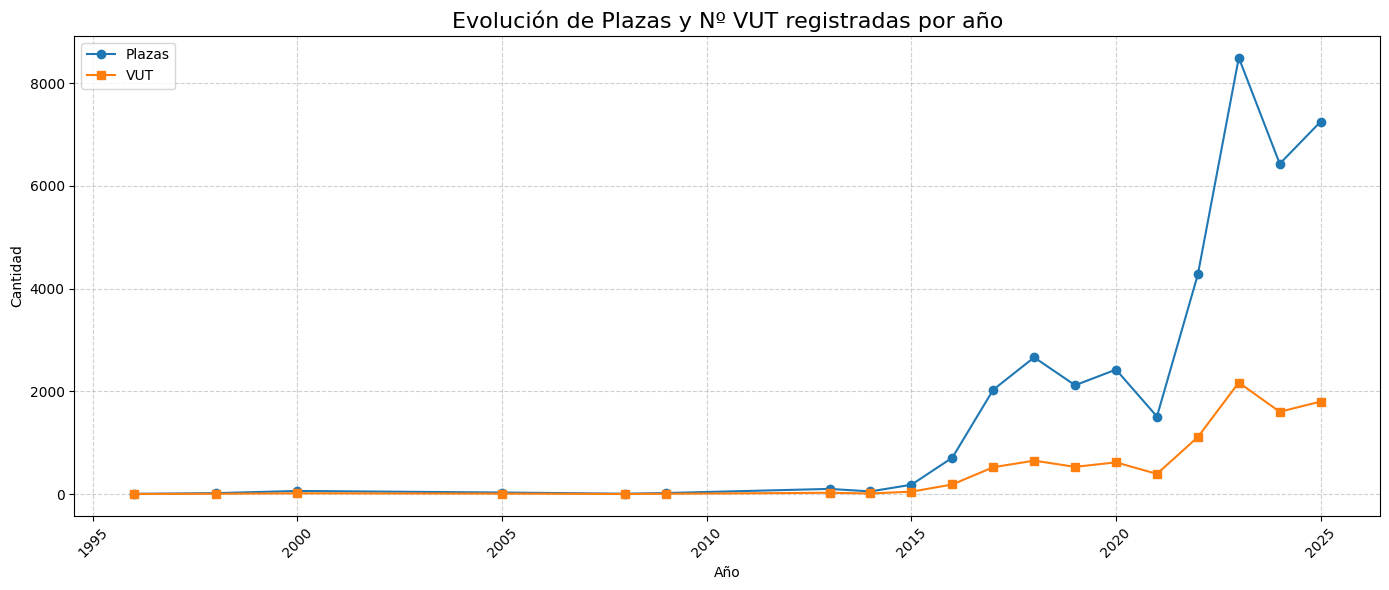

In [18]:
# agrupamos por año para ver cuántas VUT y plazas se dieron de alta cada año
datos = df_vut_limpio.groupby('Año_alta').agg({
    'Plazas totales': 'sum',
    'Año_alta': 'count'
}).rename(columns={'Año_alta': 'Nº VUT'})

display(datos)

plt.figure(figsize=(14, 6))

plt.plot(datos.index, datos['Plazas totales'], marker='o', linestyle='-', label='Plazas')
plt.plot(datos.index, datos['Nº VUT'],          marker='s', linestyle='-', label='VUT')

plt.title('Evolución de Plazas y Nº VUT registradas por año', fontsize=16)
plt.xlabel('Año')
plt.ylabel('Cantidad')
plt.xticks(rotation=45)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(loc='upper left')
plt.tight_layout()
plt.show()

Observamos en la gráfica que el crecimiento no es lineal, sino que se acelera a partir de 2017-2018. La caída de 2021 por el COVID-19 es visible, pero la recuperación posterior es inmediata y alcanza valores máximos en 2023 con 2.170 VUTs registradas y casi 8.500 plazas. En 2024 hay un descenso respecto al año anterior, pero se mantiene muy por encima de los niveles de 2022, esto podría interpretarse como una ligera corrección despues del boom de 2023. De aquí podemos concluir que el sector VUT en Torrevieja no se ha estabilizado, sino que sigue en crecimiento activo.

Por otro lado, la diferencia entre la curva de VUT y la de plazas se mantiene bastante constante, lo que sugiere que el tamaño medio de las viviendas nuevas no ha variado mucho con el tiempo (aproximadamente 4 plazas por VUT de media).

### B. DATOS INE: VIVIENDAS, PLAZAS Y PORCENTAJE SOBRE EL TOTAL CENSAL

#### 1. Identificación y origen
El INE publica semestralmente datos sobre VUT en municipios turísticos a través de la *Encuesta de Ocupación en Apartamentos Turísticos (EHAT)*. Para Torrevieja disponemos de dos archivos complementarios:
- `viviendas_turisticas_plazas_y_plazas_por_vivienda_turistica.csv`: número de VUT, plazas y ratio plazas/VUT.
- `porcentaje_viviendas_turisticas_sobre_el_total_de_viviendas_censadas.csv`: qué porcentaje del parque total representan las VUT.

Los dos archivos tienen cortes en **febrero** (temporada baja) y **agosto** (temporada alta), desde 2020 hasta 2025. Esto nos permite comparar no solo la tendencia, sino también la oscilación estacional dentro de cada año.

#### 2. Estado inicial y EDA
Los números vienen en formato europeo (punto como separador de miles, coma como decimal) y el campo `Periodo` usa el formato `AAAAMmm` (por ejemplo `2024M08`), así que hay que parsearlos antes de trabajar con ellos.

#### 3. Limpieza y transformación


In [19]:
# cargamos los dos archivos del INE
df_plazas = pd.read_csv('../DATASETS/RETO 3/DATASETS ORIGINALES/viviendas_turisticas_plazas_y_plazas_por_vivienda_turistica.csv', encoding="latin-1", sep=";")
df_pct = pd.read_csv('C:/Users/itsas/OneDrive - UNIVERSIDAD ALICANTE/Escritorio/MASTER/ASIGNATURAS/2CUATRI/MINERÍA DE DATOS/Grupal/Practica3git/Turismo-Mineria-Datos/DATASETS/RETO 3/DATASETS ORIGINALES/porcentaje_viviendas_turisticas_sobre_el_total_de_viviendas_censadas.csv', encoding="latin-1", sep=";")

print("EDA - plazas viviendas turísticas (INE)")
display(df_plazas.head())
print(f"Dimensiones: {df_plazas.shape}")
print(f"Tipos en 'Viviendas y plazas': {df_plazas['Viviendas y plazas'].unique()}")

print("\nEDA - porcentaje VUT sobre parque censado (INE)")
display(df_pct.head())
print(f"Dimensiones: {df_pct.shape}")

# función para limpiar números en formato europeo
def limpiar_numero(n):
    return pd.to_numeric(
        n.astype(str).str.replace('.', '', regex=False).str.replace(',', '.', regex=False),
        errors='coerce'
    )

# función para parsear el periodo 'AAAAMmm' a datetime
def parsear_periodo(n):
    return pd.to_datetime(n, format='%YM%m', errors='coerce')

# limpiamos el dataframe de plazas
df_plazas_limpio = df_plazas.copy()
df_plazas_limpio['Total']  = limpiar_numero(df_plazas_limpio['Total'])
df_plazas_limpio['Fecha']  = parsear_periodo(df_plazas_limpio['Periodo'])
df_plazas_limpio['Año']    = df_plazas_limpio['Fecha'].dt.year
df_plazas_limpio['Mes']    = df_plazas_limpio['Fecha'].dt.month
df_plazas_limpio['Temporada'] = df_plazas_limpio['Mes'].map({2: 'Invierno', 8: 'Verano'})

# pivotamos para tener una columna por tipo de métrica (VUT, Plazas, Ratio)
df_plazas_pivot = df_plazas_limpio.pivot_table(
    index=['Fecha', 'Año', 'Mes', 'Temporada'],
    columns='Viviendas y plazas',
    values='Total'
).reset_index()
df_plazas_pivot.columns.name = None

print("\nDataset plazas pivotado:")
display(df_plazas_pivot.sort_values('Fecha'))

# limpiamos el dataframe de porcentajes
df_pct_limpio = df_pct.copy()
df_pct_limpio['Total']     = limpiar_numero(df_pct_limpio['Total'])
df_pct_limpio['Fecha']     = parsear_periodo(df_pct_limpio['Periodo'])
df_pct_limpio['Año']       = df_pct_limpio['Fecha'].dt.year
df_pct_limpio['Mes']       = df_pct_limpio['Fecha'].dt.month
df_pct_limpio['Temporada'] = df_pct_limpio['Mes'].map({2: 'Invierno', 8: 'Verano', 5: 'Primavera', 11: 'Otoño'})

print("\nDataset porcentaje limpio:")
display(df_pct_limpio[['Fecha', 'Temporada', 'Total']].sort_values('Fecha'))

EDA - plazas viviendas turísticas (INE)


,Total Nacional,Comunidades y Ciudades Autónomas,Provincias,Municipios,Viviendas y plazas,Periodo,Total
0,Total Nacional,10 Comunitat Valenciana,03 Alicante/Alacant,03133 Torrevieja,Viviendas turísticas,2025M11,3.647
1,Total Nacional,10 Comunitat Valenciana,03 Alicante/Alacant,03133 Torrevieja,Viviendas turísticas,2025M05,4.927
2,Total Nacional,10 Comunitat Valenciana,03 Alicante/Alacant,03133 Torrevieja,Viviendas turísticas,2024M11,5.140
3,Total Nacional,10 Comunitat Valenciana,03 Alicante/Alacant,03133 Torrevieja,Viviendas turísticas,2024M08,5.411
4,Total Nacional,10 Comunitat Valenciana,03 Alicante/Alacant,03133 Torrevieja,Viviendas turísticas,2024M02,4.454


Dimensiones: (36, 7)
Tipos en 'Viviendas y plazas': <StringArray>
['Viviendas turísticas', 'Plazas', 'Plazas por vivienda turística']
Length: 3, dtype: str

EDA - porcentaje VUT sobre parque censado (INE)


,Total Nacional,Comunidades y Ciudades Autónomas,Provincias,Municipios,Periodo,Total
0,Total Nacional,10 Comunitat Valenciana,03 Alicante/Alacant,03133 Torrevieja,2025M11,"2,97"
1,Total Nacional,10 Comunitat Valenciana,03 Alicante/Alacant,03133 Torrevieja,2025M05,"4,01"
2,Total Nacional,10 Comunitat Valenciana,03 Alicante/Alacant,03133 Torrevieja,2024M11,"4,19"
3,Total Nacional,10 Comunitat Valenciana,03 Alicante/Alacant,03133 Torrevieja,2024M08,"4,41"
4,Total Nacional,10 Comunitat Valenciana,03 Alicante/Alacant,03133 Torrevieja,2024M02,"3,63"


Dimensiones: (12, 6)

Dataset plazas pivotado:


,Fecha,Año,Mes,Temporada,Plazas,Plazas por vivienda turística,Viviendas turísticas
0,2020-08-01,2020,8,Verano,18279.0,4.76,3839.0
1,2021-02-01,2021,2,Invierno,16917.0,4.74,3571.0
2,2021-08-01,2021,8,Verano,16527.0,4.75,3476.0
3,2022-02-01,2022,2,Invierno,16100.0,4.74,3397.0
4,2022-08-01,2022,8,Verano,17349.0,4.72,3679.0
5,2023-02-01,2023,2,Invierno,17679.0,4.73,3740.0
6,2023-08-01,2023,8,Verano,21594.0,4.71,4580.0
7,2024-02-01,2024,2,Invierno,21022.0,4.72,4454.0
8,2024-08-01,2024,8,Verano,25488.0,4.71,5411.0



Dataset porcentaje limpio:


,Fecha,Temporada,Total
11,2020-08-01,Verano,3.14
10,2021-02-01,Invierno,2.92
9,2021-08-01,Verano,2.84
8,2022-02-01,Invierno,2.78
7,2022-08-01,Verano,3.01
6,2023-02-01,Invierno,3.06
5,2023-08-01,Verano,3.73
4,2024-02-01,Invierno,3.63
3,2024-08-01,Verano,4.41
2,2024-11-01,Otoño,4.19


Los datos del INE son más escasos en cuanto a rango temporal (2020-2025) pero en este trabajo nos sirven porque son independientes del registro oficial y permiten ver la oscilación estacional. 

Podemos observar que las cifras de verano siempre son superiores a las de invierno (menos en 2021, seguramnete por el COVID), lo que refleja que hay VUT que solo están activas en temporada alta. Esto es coherente con el modelo turístico de la ciudad.

In [20]:
# guardamos los dos CSVs limpios

df_plazas_pivot.to_csv(
    '../DATASETS/RETO 3/DATASETS MODIFICADOS/plazas_limpio.csv',
    index=False,
    sep=";",
    encoding='utf-8-sig'
)       
df_pct_limpio.to_csv(
    '../DATASETS/RETO 3/DATASETS MODIFICADOS/porcentaje_limpio.csv',
    index=False,
    sep=";",
    encoding='utf-8-sig'
)        

### C. EVOLUCIÓN DEL PARQUE DE VIVIENDAS (Censo INE 2001, 2011, 2021)

#### 1. Identificación y origen
El INE publica el *Censo de Población y Viviendas* cada 10 años. El archivo `evolucion_viviendas_2001_2021.csv` recoge los tres últimos cortes (2001, 2011, 2021) con la distribución entre viviendas principales, secundarias y vacías.

Esta fuente es importante para saber sobre qué base de viviendas totales operan las VUT, y especialmente cuántas viviendas no principales hay disponibles para convertirse en VUT.

#### 2. Observaciones del EDA
- Solo hay 3 filas (2001, 2011, 2021), lo que nos limita el análisis a comparaciones puntuales entre décadas.
- Los datos de 2021 tienen `NaN` en `Viviendas_Secundarias` y `Viviendas_Vacias` porque el Censo de 2021 usó una metodología distinta que todavía no desagrega completamente esas categorías.

#### 3. Limpieza y transformación

In [21]:
# cargamos los datos censales del parque de viviendas
df_censo = pd.read_csv('../DATASETS/RETO 3/DATASETS ORIGINALES/evolucion_viviendas_2001_2021.csv', sep=";")


print("EDA – evolucion_viviendas_2001_2021.csv")
print(f"Dimensiones: {df_censo.shape}")
display(df_censo)
print("\nNulos por columna:")
print(df_censo.isnull().sum())

# calculamos qué % del parque son viviendas no principales (en los años con datos)
df_censo['Pct_No_Principales'] = (df_censo['Viviendas_No_Principales'] / df_censo['Total_Viviendas'] * 100).round(1)
df_censo['Pct_Secundarias']    = (df_censo['Viviendas_Secundarias'] / df_censo['Total_Viviendas'] * 100).round(1)

print("\nDataset censal con porcentajes:")
display(df_censo)


EDA – evolucion_viviendas_2001_2021.csv
Dimensiones: (3, 6)


,Año,Total_Viviendas,Viviendas_Principales,Viviendas_No_Principales,Viviendas_Secundarias,Viviendas_Vacias
0,2001,102363,21565,80643,61745.0,18898.0
1,2011,122327,39855,82472,62585.0,19887.0
2,2021,122736,36829,85907,NaN,NaN



Nulos por columna:
Año                         0
Total_Viviendas             0
Viviendas_Principales       0
Viviendas_No_Principales    0
Viviendas_Secundarias       1
Viviendas_Vacias            1
dtype: int64

Dataset censal con porcentajes:


,Año,Total_Viviendas,Viviendas_Principales,Viviendas_No_Principales,Viviendas_Secundarias,Viviendas_Vacias,Pct_No_Principales,Pct_Secundarias
0,2001,102363,21565,80643,61745.0,18898.0,78.8,60.3
1,2011,122327,39855,82472,62585.0,19887.0,67.4,51.2
2,2021,122736,36829,85907,NaN,NaN,70.0,NaN


Los datos censales revelan que casi el 80% de las viviendas son no principales (secundarias o vacías). Es decir, la mayor parte del parque inmobiliario no es de uso habitual por sus propietarios. Este dato contextualiza perfectamente el modelo turístico residencial de Torrevieja: gran parte del stock de viviendas existe para ser usado de forma temporal, y las VUT son la expresión más visible y regulada de ese uso.

Que en 2021 el INE no pueda desagregar secundarias de vacías es una limitación metodológica del nuevo censo. Trabajaremos con el dato de "No Principales" como base de referencia, que sí está disponible para los tres cortes y nos permite comparar la serie completa.

### D. PRECIOS DE VIVIENDA Y ALQUILER

#### 1. Identificación y origen
Disponemos de dos series temporales de precios en Torrevieja:
- `precios_vivienda.csv`: precio medio por m² de compraventa (mensual, desde 2006).
- `precio_alquileres.csv`: precio medio por m² de alquiler (mensual, desde 2008).

Estos datos nos permiten explorar la correlación entre el crecimiento de las VUT y el encarecimiento del mercado inmobiliario local.

#### 2. Particularidades del formato
- `precio_alquileres.csv` está codificado en *UTF-16 con separador de tabulación*, a diferencia del resto de archivos que vienen en latin-1 o UTF-8.
- El campo `Mes` viene en texto español (por ejemplo `"Febrero 2026"`), así que hay que mapearlo a inglés antes de parsearlo como fecha.

#### 3. Carga y transformación


In [25]:
# precios de compraventa

df_precio_comp = pd.read_csv('../DATASETS/RETO 3/DATASETS ORIGINALES/precios_vivienda.csv', sep=";", encoding='latin-1')


# convertimos a numérico (algunos valores "nd" se convierten en NaN)
df_precio_comp['Precio_m2'] = pd.to_numeric(df_precio_comp['Precio_m2'], errors='coerce')
# parseamos la fecha y ordenamos
df_precio_comp['Fecha'] = pd.to_datetime(df_precio_comp['Mes'], format='%d/%m/%Y', errors='coerce')
df_precio_comp = df_precio_comp.sort_values('Fecha').dropna(subset=['Fecha'])
df_precio_comp['Año'] = df_precio_comp['Fecha'].dt.year

# precios de alquiler
df_precio_alq = pd.read_csv('C:/Users/itsas/OneDrive - UNIVERSIDAD ALICANTE/Escritorio/MASTER/ASIGNATURAS/2CUATRI/MINERÍA DE DATOS/Grupal/Practica3git/Turismo-Mineria-Datos/DATASETS/RETO 3/DATASETS ORIGINALES/precio_alquileres.csv', sep="\t", encoding='utf-6')

# traducimos el mes para poder parsearlo
meses_es = {
    'Enero': 'January', 'Febrero': 'February', 'Marzo': 'March',
    'Abril': 'April', 'Mayo': 'May', 'Junio': 'June',
    'Julio': 'July', 'Agosto': 'August', 'Septiembre': 'September',
    'Octubre': 'October', 'Noviembre': 'November', 'Diciembre': 'December'
}
df_precio_alq['Mes_in'] = df_precio_alq['Mes'].replace(meses_es, regex=True)
df_precio_alq['Fecha']  = pd.to_datetime(df_precio_alq['Mes_in'], format='%B %Y', errors='coerce')
# ordenamos
df_precio_alq = df_precio_alq.sort_values('Fecha').dropna(subset=['Fecha'])
df_precio_alq['Año'] = df_precio_alq['Fecha'].dt.year

# EDA
print("EDA – Precios de compraventa:")
display(pd.concat([df_precio_comp.head(3), df_precio_comp.tail(3)]))
print(f"\nRango: {df_precio_comp['Fecha'].min().strftime('%Y-%m')} → {df_precio_comp['Fecha'].max().strftime('%Y-%m')}")
print(f"Precio mín: {df_precio_comp['Precio_m2'].min()} €/m²  |  Precio máx: {df_precio_comp['Precio_m2'].max()} €/m²")

print("\nEDA – Precios de alquiler:")
display(pd.concat([df_precio_alq.head(3), df_precio_alq.tail(3)]))
print(f"\nRango: {df_precio_alq['Fecha'].min().strftime('%Y-%m')} → {df_precio_alq['Fecha'].max().strftime('%Y-%m')}")
print(f"Precio mín: {df_precio_alq['Precio_m2'].min()} €/m²  |  Precio máx: {df_precio_alq['Precio_m2'].max()} €/m²")


LookupError: unknown encoding: utf-6

El mínimo del precio de compraventa coincide aproximadamente con el inicio del despegue del sector VUT (hacia 2013-2015). Por otro lado, el alquiler muestra un aumento constante desde 2015, que es justo cuando el sector VUT empieza a crecer de forma más intensa, lo que sugiere una relación directa entre el auge de este modelo y el increcimiento de los precios.

## 3. RESULTADOS Y ANÁLISIS

Una vez tenemos los datos limpios y preparados, hacemos el análisis exploratorio. Hemos estructurado el análisis en cuatro bloques, cada uno dedicado a responder una de las preguntas del reto:

1. **¿Cuántas VUT hay y cómo son?** 
2. **¿Cómo han evolucionado?**
3. **¿Dónde se concentran?**
4. **¿Cuánto representan sobre el parque total?**

### 3.1 DIMENSIÓN ACTUAL DEL SECTOR VUT

RESUMEN DEL SECTOR VUT
  - Nº total de VUT registradas: 9694
  - Total de plazas generadas:   38362
  - Plazas medias por VUT:       3.96
  - Superficie media:            73.79m²
  - % Estudios:                  0.78%


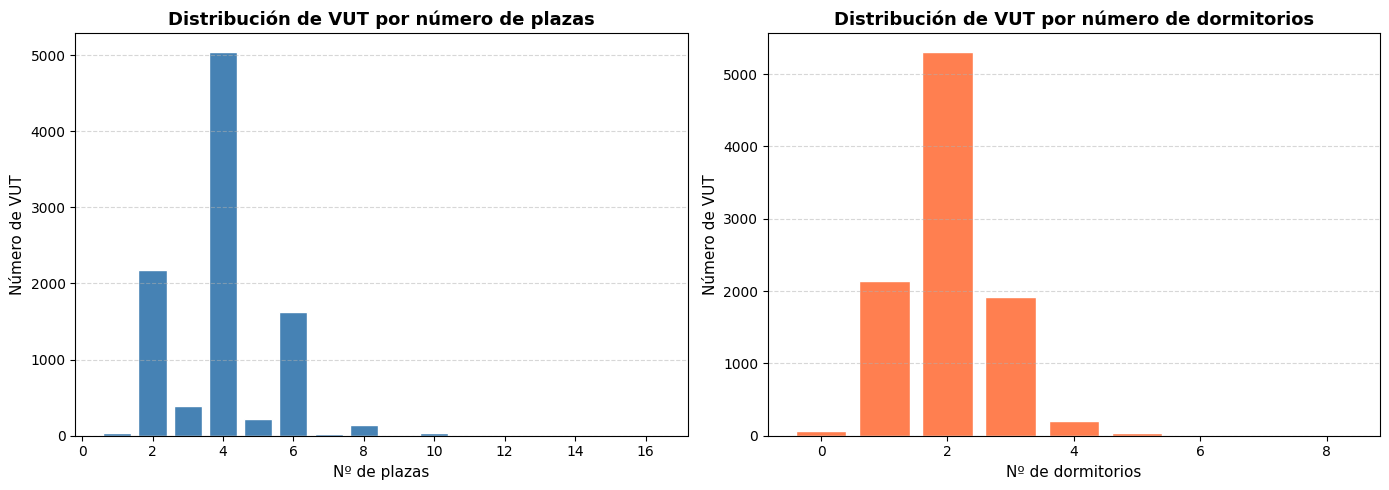

In [ ]:
# calculamos las métricas principales del sector
total_vuts = len(df_vut_limpio)
total_plazas = df_vut_limpio['Plazas totales'].sum()
media_plazas = df_vut_limpio['Plazas totales'].mean()
media_sup = df_vut_limpio['Superficie'].mean()
pct_estudio = (df_vut_limpio['Estudio'] == 'S').sum() / total_vuts * 100

print("RESUMEN DEL SECTOR VUT")
print(f"  - Nº total de VUT registradas: {total_vuts}")
print(f"  - Total de plazas generadas:   {total_plazas}")
print(f"  - Plazas medias por VUT:       {media_plazas:.2f}")
print(f"  - Superficie media:            {media_sup:.2f}m²")
print(f"  - % Estudios:                  {pct_estudio:.2f}%")

# distribución de plazas y dormitorios por vut

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# histograma de plazas
ax = axes[0]
num_plazas = df_vut_limpio['Plazas totales'].value_counts().sort_index()
ax.bar(num_plazas.index, num_plazas.values, color='steelblue', edgecolor='white')
ax.set_title('Distribución de VUT por número de plazas', fontsize=13, fontweight='bold')
ax.set_xlabel('Nº de plazas', fontsize=11)
ax.set_ylabel('Número de VUT', fontsize=11)
ax.grid(axis='y', linestyle='--', alpha=0.5)

# histograma de dormitorios
ax2 = axes[1]
df_vut_limpio['Total dormitorios'] = df_vut_limpio['Total dormitorios'].dropna().astype(int)
num_dorm = df_vut_limpio['Total dormitorios'].value_counts().sort_index()
ax2.bar(num_dorm.index, num_dorm.values, color='coral', edgecolor='white')
ax2.set_title('Distribución de VUT por número de dormitorios', fontsize=13, fontweight='bold')
ax2.set_xlabel('Nº de dormitorios', fontsize=11)
ax2.set_ylabel('Número de VUT', fontsize=11)
ax2.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

El sector VUT de Torrevieja cuenta con **9.694 viviendas** que suman un total de **38.362 plazas**. Con una **media de casi 4 plazas** por apartamento, el perfil más alquilado es la vivienda pequeña (**4 plazas, 2 dormitorios**). Un porcentaje muy pequeño (0.78%) son estudios, lo que nos dice que la oferta está orientada a grupos pequeños o familias más que a turistas individuales.

La superficie media es de **73.79m²**, lo que nos confirma este perfil: la mayoría son apartamentos estándar del parque inmobiliario vacacional de la zona.

### 3.2 EVOLUCIÓN TEMPORAL DEL SECTOR

Analizamos cómo ha crecido el número de altas anuales y el stock acumulado, y cruzamos estos datos con los del INE para tener dos fuentes independientes sobre la misma evolución.


Altas anuales de VUT en Torrevieja:


,Año_alta,Nuevas_VUT,Nuevas_Plazas,Stock_VUT_Acumulado,Stock_Plazas_Acumulado,Crecimiento_pct
9,2016,186,707,303,1177,304.347826
10,2017,522,2030,825,3207,180.645161
11,2018,650,2660,1475,5867,24.521073
12,2019,529,2118,2004,7985,-18.615385
13,2020,617,2422,2621,10407,16.635161
14,2021,392,1509,3013,11916,-36.466775
15,2022,1110,4275,4123,16191,183.163265
16,2023,2170,8494,6293,24685,95.495495
17,2024,1601,6428,7894,31113,-26.221198
18,2025,1800,7249,9694,38362,12.429731


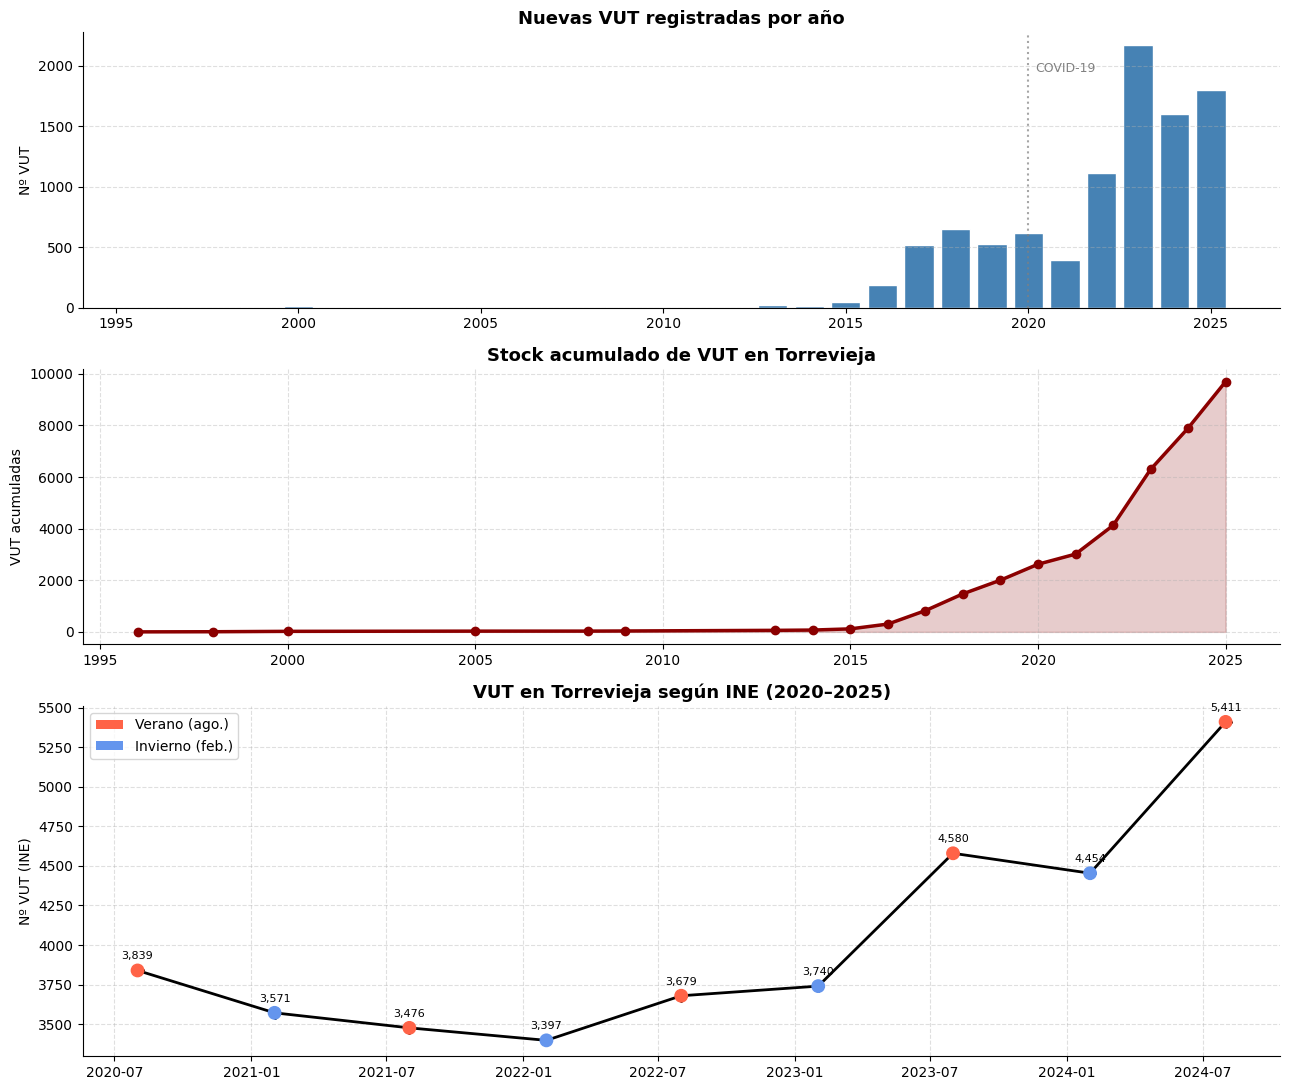

In [ ]:
# agrupamos vuts por año de alta
altas_anuales = df_vut_limpio.groupby('Año_alta').agg(
    Nuevas_VUT=('Plazas totales', 'count'), # vuts nuevas ese año
    Nuevas_Plazas=('Plazas totales', 'sum') # plazas nuevas ese año
).reset_index()

# cuantas vut/plazas existen en cada año (stock acumulado)
altas_anuales['Stock_VUT_Acumulado'] = altas_anuales['Nuevas_VUT'].cumsum()
altas_anuales['Stock_Plazas_Acumulado'] = altas_anuales['Nuevas_Plazas'].cumsum()

# % de crecimiento por año
altas_anuales['Crecimiento_pct'] = altas_anuales['Nuevas_VUT'].pct_change() * 100

print("Altas anuales de VUT en Torrevieja:")
display(altas_anuales.tail(10))


#graficos

fig, axes = plt.subplots(3,1, figsize=(13, 11), sharex=False, gridspec_kw={'height_ratios': [1.1, 1.1, 1.4]})

# nuevas vut
ax1 = axes[0]

ax1.bar(
    altas_anuales['Año_alta'],
    altas_anuales['Nuevas_VUT'],
    color='steelblue',
    edgecolor='white'
)

ax1.set_title('Nuevas VUT registradas por año', fontsize=13, fontweight='bold')
ax1.set_ylabel('Nº VUT')
ax1.grid(axis='y', linestyle='--', alpha=0.4)

# línea covid (para ver el antes y despues)
ax1.axvline(2020, linestyle=':', color='gray', alpha=0.7)
ax1.text(2020.2, altas_anuales['Nuevas_VUT'].max()*0.9, 'COVID-19',
         color='gray', fontsize=9)

# vut acumuladas
ax2 = axes[1]

ax2.plot(
    altas_anuales['Año_alta'],
    altas_anuales['Stock_VUT_Acumulado'],
    color='darkred',
    marker='o',
    linewidth=2.5
)

ax2.fill_between(
    altas_anuales['Año_alta'],
    altas_anuales['Stock_VUT_Acumulado'],
    alpha=0.2,
    color='darkred'
)

ax2.set_title('Stock acumulado de VUT en Torrevieja', fontsize=13, fontweight='bold')
ax2.set_ylabel('VUT acumuladas')
ax2.grid(linestyle='--', alpha=0.4)


# datos INE (2020-2025)
ax3 = axes[2]

df_vut_ine = df_plazas_pivot[
    df_plazas_pivot['Viviendas turísticas'].notna()
].sort_values('Fecha')

colores_temp = df_vut_ine['Temporada'].map({
    'Invierno': 'cornflowerblue',
    'Verano': 'tomato'
})

ax3.plot(
    df_vut_ine['Fecha'],
    df_vut_ine['Viviendas turísticas'],
    color='black',
    linewidth=2,
    marker='D',
    zorder=3
)

ax3.scatter(
    df_vut_ine['Fecha'],
    df_vut_ine['Viviendas turísticas'],
    c=colores_temp.values,
    s=80,
    zorder=4
)

# leyenda
from matplotlib.patches import Patch

legend_elements = [
    Patch(facecolor='tomato', label='Verano (ago.)'),
    Patch(facecolor='cornflowerblue', label='Invierno (feb.)')
]

ax3.legend(handles=legend_elements, loc='upper left')

# etiquetas
for _, row in df_vut_ine.iterrows():
    ax3.annotate(
        f"{int(row['Viviendas turísticas']):,}",
        (row['Fecha'], row['Viviendas turísticas']),
        textcoords='offset points',
        xytext=(0, 8),
        ha='center',
        fontsize=8
    )

ax3.set_title('VUT en Torrevieja según INE (2020–2025)', fontsize=13, fontweight='bold')
ax3.set_ylabel('Nº VUT (INE)')
ax3.grid(linestyle='--', alpha=0.4)

for ax in axes:
    ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.show()

En la evolución temporal observamos tres fases:

1. **Fase de despegue (hasta 2017)**: crecimiento moderado, el sector VUT empieza a asomar pero aún no domina el parque inmobiliario.
2. **Fase de aceleración (2018-2020)**: el número de altas anuales se dispara, consolida por encima de las 500-600 unidades, probablemente impulsado por el auge de plataformas digitales como Airbnb y el aumento de la demanda turística post-crisis.
3. **Pausa COVID (2020-2021)** y **reactivación máxima (2022-2025)**: la caída por la pandemia fue relativamente breve. La recuperación posterior supera los niveles previos, alcanzando un pico absoluto en 2023 con 2.170 nuevas altas.

Si lo comparamos con los datos del INE, aunque ambas fuentes muestran la misma tendencia, las cifras absolutas son diferentes (el INE mide la ocupación efectiva en un momento dado, no el stock total del registro). La oscilación entre los puntos rojos (verano) y los azules (invierno) en los datos del INE confirma que una parte del stock solo opera en temporada alta.

### 3.3 DISTRIBUCIÓN TERRITORIAL POR CÓDIGO POSTAL

El código postal es el único proxy geográfico disponible en el registro. Aunque es una granularidad limitada, nos permite identificar si hay zonas con concentración especialmente alta de VUT y si los perfiles de las viviendas difieren según la zona.

Representamos los datos de dos formas complementarias: un gráfico de barras horizontales con el número de VUT por zona, y un mapa aproximado de Torrevieja donde el tamaño de cada burbuja refleja la densidad de VUT en esa área. El mapa usa coordenadas aproximadas asignadas manualmente a cada CP, así que es orientativo, pero ayuda a visualizar la distribución espacial de forma más intuitiva que una tabla.


Distribución de VUT por código postal:


,CP,Zona,N_VUT,Pct_VUT,Total_Plazas,Media_Plazas,Media_Superficie
0,03180,Centro,5817,60.0,22386,3.8,70.1
5,03185,La Veleta / Acequión,925,9.5,3983,4.3,90.5
3,03183,Cabo Cervera,919,9.5,3778,4.1,76.5
2,03182,La Siesta,776,8.0,2881,3.7,66.9
7,03188,La Mata,530,5.5,2059,3.9,68.0
1,03181,Casco Antiguo,305,3.2,1188,3.9,73.6
4,03184,El Chaparral,290,3.0,1379,4.8,92.3
6,03186,Los Balcones / Los Altos,132,1.4,708,5.4,157.4


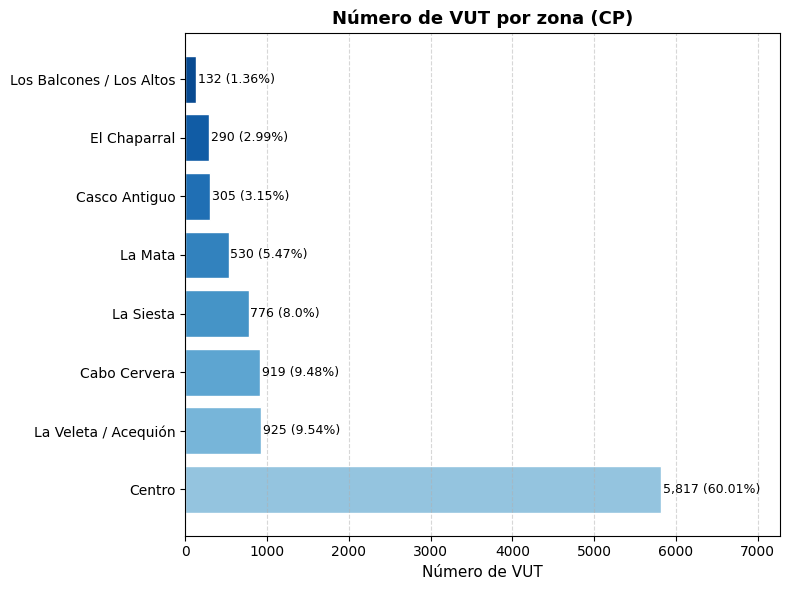

In [ ]:
# referencia de zonas de torrevieja por CP
zonas_cp = {
    '03180': 'Centro',
    '03181': 'Casco Antiguo',
    '03182': 'La Siesta',
    '03183': 'Cabo Cervera',
    '03184': 'El Chaparral',
    '03185': 'La Veleta / Acequión',
    '03186': 'Los Balcones / Los Altos',
    '03188': 'La Mata'
}

# coordenadas aproximadas de cada CP
coords_cp = {
    '03180': (37.9840, -0.6833),
    '03181': (37.9780, -0.6854),
    '03182': (37.9798, -0.67168),
    '03183': (37.9996, -0.6543),
    '03184': (38.0109, -0.695028),
    '03185': (37.9700, -0.6950),
    '03186': (37.96101, -0.72763),
    '03188': (38.01812, -0.65637)
}

# agrupamos VUTs por CP
df_geo = df_vut_limpio.groupby('CP').agg(
    N_VUT=('Plazas totales', 'count'),
    Total_Plazas=('Plazas totales', 'sum'),
    Media_Plazas=('Plazas totales', 'mean'),
    Media_Superficie=('Superficie', 'mean')
).reset_index()

df_geo['Zona'] = df_geo['CP'].map(zonas_cp).fillna('Otras zonas')
df_geo['Pct_VUT'] = (df_geo['N_VUT'] / df_geo['N_VUT'].sum() * 100).round(2)
df_geo['Lat'] = df_geo['CP'].map(lambda cp: coords_cp.get(cp, (None, None))[0])
df_geo['Lon'] = df_geo['CP'].map(lambda cp: coords_cp.get(cp, (None, None))[1])
df_geo = df_geo.sort_values('N_VUT', ascending=False)

print("Distribución de VUT por código postal:")
display(df_geo[['CP', 'Zona', 'N_VUT', 'Pct_VUT', 'Total_Plazas', 'Media_Plazas', 'Media_Superficie']].round(1))

plt.figure(figsize=(8, 6))

# barras horizontales
colores = cm.Blues(np.linspace(0.4, 0.9, len(df_geo)))
barras  = plt.barh(df_geo['Zona'], df_geo['N_VUT'], color=colores, edgecolor='white')
plt.xlabel('Número de VUT', fontsize=11)
plt.title('Número de VUT por zona (CP)', fontsize=13, fontweight='bold')
plt.grid(axis='x', linestyle='--', alpha=0.5)
for bar, pct in zip(barras, df_geo['Pct_VUT']):
    plt.text(bar.get_width() + 20, bar.get_y() + bar.get_height() / 2,
            f'{int(bar.get_width()):,} ({pct}%)', va='center', fontsize=9)
plt.xlim(0, df_geo['N_VUT'].max() * 1.25)

plt.tight_layout()
plt.show()

#mapa de burbujas

import folium
from folium.plugins import MarkerCluster

df_map = df_geo.dropna(subset=['Lat', 'Lon'])

# escala de burbujas
max_vut = df_map['N_VUT'].max()

# mapa centrado en Torrevieja
m = folium.Map(
    location=[37.970, -0.690],
    zoom_start=12,
    tiles='OpenStreetMap'
)

# colormapping
import matplotlib.cm as cm
import matplotlib.colors as mcolors

norm = mcolors.Normalize(vmin=df_map['N_VUT'].min(), vmax=max_vut)
colormap = cm.get_cmap('YlOrRd')

for _, row in df_map.iterrows():
    # color segun N_VUT
    rgba = colormap(norm(row['N_VUT']))
    color_hex = mcolors.to_hex(rgba)

    # radio proporcional
    radio = int(10 + (row['N_VUT'] / max_vut) * 40)

    folium.CircleMarker(
        location=[row['Lat'], row['Lon']],
        radius=radio,
        color='gray',
        weight=1,
        fill=True,
        fill_color=color_hex,
        fill_opacity=0.75,
        tooltip=folium.Tooltip(
            f"<b>{row['Zona']}</b><br>"
            f"CP: {row['CP']}<br>"
            f"VUT: {int(row['N_VUT'])} ({row['Pct_VUT']}%)<br>"
            f"Total plazas: {int(row['Total_Plazas'])}<br>"
            f"Media plazas: {row['Media_Plazas']:.1f}<br>"
            f"Media superficie: {row['Media_Superficie']:.1f} m²"
        ),
        popup=folium.Popup(
            f"<b>{row['Zona']}</b><br>CP {row['CP']}<br>{int(row['N_VUT'])} VUTs",
            max_width=200
        )
    ).add_to(m)

    # etiqueta encima de la burbuja
    folium.Marker(
        location=[row['Lat'], row['Lon']],
        icon=folium.DivIcon(
            html=f'<div style="font-size:9px; font-weight:bold; color:black; '
                 f'text-align:center; white-space:nowrap;">'
                 f'{row["CP"]}<br>({int(row["N_VUT"])})</div>',
            icon_size=(60, 30),
            icon_anchor=(30, 15)
        )
    ).add_to(m)

# guardamos mapa y mostramos
m.save('../DATASETS/RETO 3/mapa_vut_torrevieja.html')
m

Observamos que la distribución no es nada uniforme. El **CP 03180 (Centro)** concentra el **60% de las VUT** (5.817 viviendas). Es lógico, ya que es la zona con mayor accesibilidad, más servicios y proximidad al paseo marítimo.

Por otro lado, los CPs periféricos (como 03184 o 03186) tienen volúmenes mucho más pequeños pero con viviendas que tienden a ser más grandes, es decir, más metros cuadrados y más plazas por VUT, pasamos de los 70m² del centro a 157m² de media en Los Balcones, con una media de 5,4 plazas. Estas viviendas seguramente estén orientadas a familias grandes o estancias más largas.

Esta concentración en el centro tiene implicaciones importantes para el acceso a la vivienda de los locales: en la zona de mayor demanda de alquiler residencial, la competencia con el uso turístico es más intensa.

### 3.4 PORCENTAJE DE VUT SOBRE EL PARQUE TOTAL DE VIVIENDAS

Para entender el verdadero peso del sector VUT en la ciudad, lo comparamos con el parque total de viviendas censado. La referencia más relevante es el porcentaje sobre las viviendas no principales, que son las que realmente compiten con las VUT por el mismo uso.

Parque total de viviendas (Censo 2021):  122,736
Viviendas no principales (2021):          85,907
VUT registradas (Registro GVA, actual):    9,694
% VUT / Total viviendas:                   7.90%
% VUT / Viviendas no principales:         11.28%



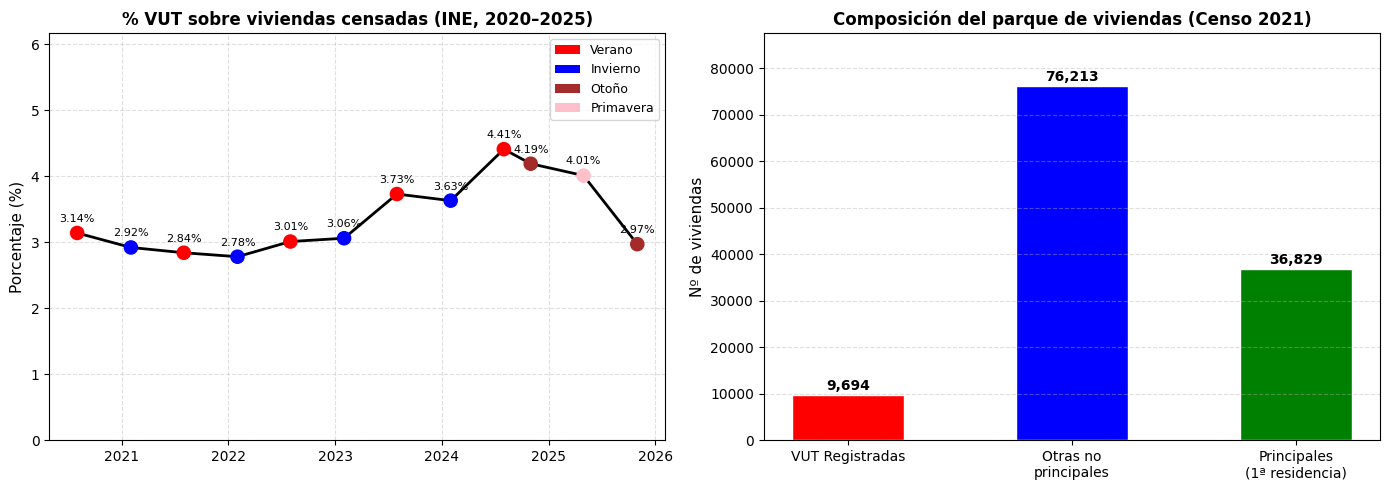

In [ ]:
# parque total (censo 2021)
total_viviendas_2021 = df_censo.loc[df_censo['Año'] == 2021, 'Total_Viviendas'].values[0]
total_no_principales = df_censo.loc[df_censo['Año'] == 2021, 'Viviendas_No_Principales'].values[0]

# % de vut en parque total y en viviendas no principales
pct_vut_sobre_total = total_vuts / total_viviendas_2021 * 100
pct_vut_sobre_no_principales = total_vuts / total_no_principales * 100

print(f"Parque total de viviendas (Censo 2021): {total_viviendas_2021:>8,}")
print(f"Viviendas no principales (2021):        {total_no_principales:>8,}")
print(f"VUT registradas (Registro GVA, actual): {total_vuts:>8,}")
print(f"% VUT / Total viviendas:                {pct_vut_sobre_total:>7.2f}%")
print(f"% VUT / Viviendas no principales:       {pct_vut_sobre_no_principales:>7.2f}%")
print()

# GRAFICO

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# serie temporal
ax = axes[0]
# ordenamos por fecha
df_pct_sorted = df_pct_limpio.sort_values('Fecha')
colores_temp = df_pct_sorted['Temporada'].map(
    {'Verano': 'red', 'Invierno': 'blue', 'Otoño': 'brown', 'Primavera': 'pink'}
).fillna('gray')

ax.plot(df_pct_sorted['Fecha'], df_pct_sorted['Total'], color='black', linewidth=2, zorder=3)
ax.scatter(df_pct_sorted['Fecha'], df_pct_sorted['Total'], c=colores_temp.values, s=90, zorder=4)

for _, row in df_pct_sorted.iterrows():
    ax.annotate(f"{row['Total']:.2f}%",
                (row['Fecha'], row['Total']),
                textcoords='offset points', xytext=(0, 8), ha='center', fontsize=8)

ax.set_title('% VUT sobre viviendas censadas (INE, 2020–2025)', fontsize=12, fontweight='bold')
ax.set_ylabel('Porcentaje (%)', fontsize=11)
ax.set_ylim(0, df_pct_sorted['Total'].max() * 1.4)
ax.grid(linestyle='--', alpha=0.4)

legend_els = [Patch(facecolor='red', label='Verano'),
              Patch(facecolor='blue', label='Invierno'),
              Patch(facecolor='brown', label='Otoño'),
              Patch(facecolor='pink', label='Primavera')]
ax.legend(handles=legend_els, fontsize=9, loc='upper right')

# composición del parque de viviendas 2021
ax2 = axes[1]
row_2021 = df_censo[df_censo['Año'] == 2021].iloc[0]
categorias  = ['VUT Registradas', 'Otras no\nprincipales', 'Principales\n(1ª residencia)']
valores     = [total_vuts,
               row_2021['Viviendas_No_Principales'] - total_vuts,
               row_2021['Viviendas_Principales']]
colores_bar = ['red', 'blue', 'green']

ax2.bar(categorias, valores, color=colores_bar, edgecolor='white', width=0.5)
ax2.set_title('Composición del parque de viviendas (Censo 2021)', fontsize=12, fontweight='bold')
ax2.set_ylabel('Nº de viviendas', fontsize=11)
ax2.grid(axis='y', linestyle='--', alpha=0.4)
for i, v in enumerate(valores):
    ax2.text(i, v + 500, f'{int(v):,}', ha='center', va='bottom', fontsize=10, fontweight='bold')
ax2.set_ylim(0, max(valores) * 1.15)

plt.tight_layout()
plt.show()

Las VUT representan casi el **8% del parque total** de viviendas de Torrevieja, una cifra que a primera vista no parece muy grande. Sin embargo, cuando el denominador cambia a las viviendas no principales, el porcentaje sube al **11.28%**, es decir, una de cada diez viviendas no principales ya está registrada como VUT.

Además, la serie temporal del INE muestra que este porcentaje ha ido creciendo desde 2020, pasando de un 3% a picos de casi 4,5% en las mediciones estacionales. El pico de agosto (temporada alta) es siempre mayor que el de febrero (menos en época COVID), lo que nos confirma que el sector VUT tiene un componente estacional claro incluso dentro del propio stock registrado.

## 4. TÉCNICAS DE MINERÍA DE DATOS

Con el análisis exploratorio ya hecho, vamos a extraer patrones que no son evidentes a simple vista:

1. **Clustering K-Means** sobre las zonas geográficas (CP) para identificar perfiles diferenciados de oferta VUT por zona.
2. **Análisis de serie temporal con regresión lineal por tramos** para ver si hay algún punto de inflexión claro en el ritmo de crecimiento del sector.
3. **Análisis de correlación y regresión lineal** para ver si existe relación entre la densificación de VUT y los precios del mercado inmobiliario.

### 4.1 CLUSTERING K-MEANS: PERFILES DE ZONAS VUT

El objetivo de este apartado es ver si los códigos postales de Torrevieja se agrupan en perfiles distintos según sus características VUT (número de viviendas, plazas totales, tamaño medio, superficie, antigüedad del registro).

Antes de aplicar el algoritmo, vamos a estandarizar las variables (media 0, desviación 1) para que ninguna variable domine el clustering solo por tener una escala mayor. Después, usamos el método del codo y el *silhouette score* para elegir el número óptimo de clusters.

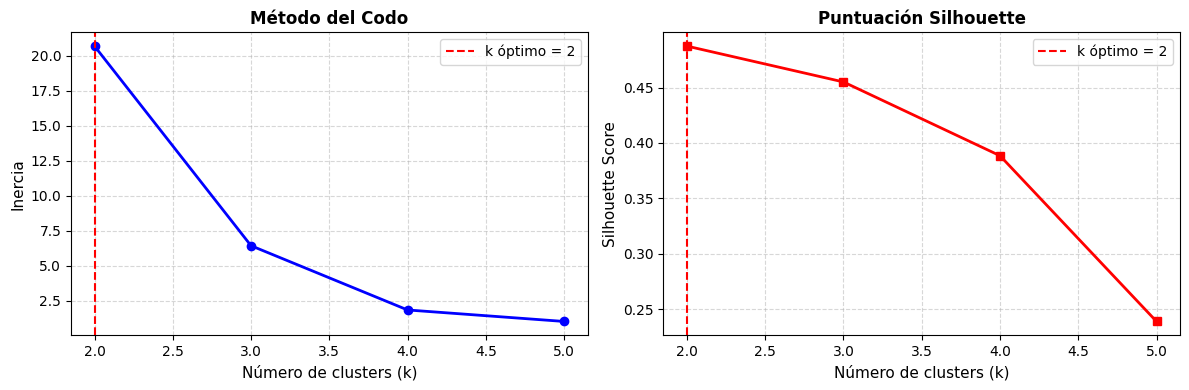

Silhouette por k: {2: 0.488, 3: 0.455, 4: 0.388, 5: 0.239}

Número óptimo de clusters: k = 2


In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# añadimos el año medio de alta como variable de antigüedad del parque VUT en cada zona
df_geo_año = df_vut_limpio.groupby('CP')['Año_alta'].mean().reset_index()
df_geo_año.columns = ['CP', 'Año_medio_alta']
df_geo_cluster = df_geo.merge(df_geo_año, on='CP')

# variables para comparar las zonas
features = ['N_VUT', 'Total_Plazas', 'Media_Plazas', 'Media_Superficie', 'Año_medio_alta']
X = df_geo_cluster[features].dropna()
idx_valido = X.index

# estandarizamos para que todas las variables estén en la misma escala
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# probamos distintos valores de k y calculamos inercia y silhouette
inertias  = []
sil_scores = []
k_range = range(2, min(len(X), 6))

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(X_scaled, labels))

# k óptimo
k_optimo = list(k_range)[sil_scores.index(max(sil_scores))]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(list(k_range), inertias, 'bo-', linewidth=2)
ax1.axvline(k_optimo, color='red', linestyle='--', linewidth=1.5,
            label=f'k óptimo = {k_optimo}')
ax1.set_title('Método del Codo', fontsize=12, fontweight='bold')
ax1.set_xlabel('Número de clusters (k)', fontsize=11)
ax1.set_ylabel('Inercia', fontsize=11)
ax1.legend(fontsize=10)
ax1.grid(linestyle='--', alpha=0.5)

ax2.plot(list(k_range), sil_scores, 'rs-', linewidth=2)
ax2.axvline(k_optimo, color='red', linestyle='--', linewidth=1.5,
            label=f'k óptimo = {k_optimo}')
ax2.set_title('Puntuación Silhouette', fontsize=12, fontweight='bold')
ax2.set_xlabel('Número de clusters (k)', fontsize=11)
ax2.set_ylabel('Silhouette Score', fontsize=11)
ax2.legend(fontsize=10)
ax2.grid(linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

print(f"Silhouette por k: {dict(zip(k_range, [round(s,3) for s in sil_scores]))}")
print(f"\nNúmero óptimo de clusters: k = {k_optimo}")


Si observamos las gráficas, el Método del Codo nos indica dónde la inercia deja de caer drásticamente; en este caso, el "quiebre" visual más claro se observa en k=3 o k=4. Sin embargo, en el Silhouette Score (que mide qué tan bien encaja cada punto en su grupo y qué tan lejos está del resto) el valor máximo está en k=2. 

Por tanto, para evitar el sobreajuste y mantener una estructura clara, elegimos el k óptimo = 2. Con este valor ajustamos el modelo final para explorar qué zonas de Torrevieja caen en cada perfil.

Resultado del clustering (k=2):


,CP,Zona,N_VUT,Total_Plazas,Media_Plazas,Media_Superficie,Año_medio_alta,Cluster
1,03185,La Veleta / Acequión,925,3983,4.3,90.5,2022,0
2,03183,Cabo Cervera,919,3778,4.1,76.5,2021,0
3,03182,La Siesta,776,2881,3.7,66.9,2022,0
4,03188,La Mata,530,2059,3.9,68.0,2021,0
5,03181,Casco Antiguo,305,1188,3.9,73.6,2021,0
6,03184,El Chaparral,290,1379,4.8,92.3,2022,0
7,03186,Los Balcones / Los Altos,132,708,5.4,157.4,2022,0
0,03180,Centro,5817,22386,3.8,70.1,2022,1



Centroides (media por cluster):


,N_VUT,Total_Plazas,Media_Plazas,Media_Superficie,Año_medio_alta
Cluster,,,,,
0,553.9,2282.3,4.3,89.3,2021
1,5817.0,22386.0,3.8,70.1,2022


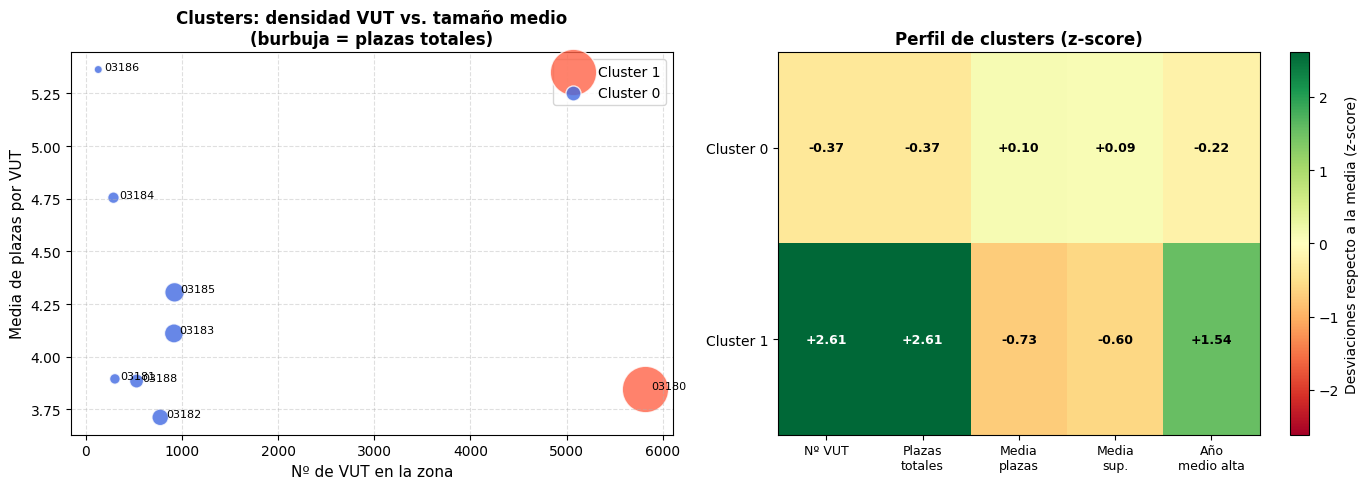


 TABLA DE INTERPRETACIÓN DE CLUSTERS


,Zonas (CP),Nº VUT total,Media plazas,Media sup. (m²),Año medio alta,Perfil
Cluster,,,,,,
0,"La Veleta / Acequión, Cabo Cervera, La Siesta,...",3877,4.3,89.3,2022,Densidad baja – presencia residual de VUT
1,Centro,5817,3.8,70.1,2022,"Alta densidad – muchas VUT pequeñas, registro ..."


In [ ]:
# ajustamos k-means con el k óptimo
km_final = KMeans(n_clusters=k_optimo, random_state=42, n_init=10)

df_geo_cluster.loc[idx_valido, 'Cluster'] = km_final.fit_predict(X_scaled)
df_geo_cluster['Cluster'] = df_geo_cluster['Cluster'].astype('Int64')

print(f"Resultado del clustering (k={k_optimo}):")
cluster = df_geo_cluster[['CP', 'Zona', 'N_VUT', 'Total_Plazas', 'Media_Plazas',
                              'Media_Superficie', 'Año_medio_alta', 'Cluster']].copy()
cluster = cluster.round(1)
cluster['Año_medio_alta'] = cluster['Año_medio_alta'].round(0).astype(int)
display(cluster.sort_values('Cluster'))

# centroides de cada cluster
print("\nCentroides (media por cluster):")
centroides = df_geo_cluster.groupby('Cluster')[features].mean().round(1)
centroides['Año_medio_alta'] = centroides['Año_medio_alta'].astype(int)
display(centroides)

# visualización de clustering
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
colores_cluster = {0: 'royalblue', 1: 'tomato', 2: 'goldenrod', 3: 'mediumseagreen'}

# scatter: densidad VUT vs tamaño medio por cluster
ax = axes[0]
for c in df_geo_cluster['Cluster'].dropna().unique():
    sub = df_geo_cluster[df_geo_cluster['Cluster'] == c]
    ax.scatter(sub['N_VUT'], sub['Media_Plazas'],
               s=sub['Total_Plazas'] / 20,
               color=colores_cluster.get(int(c), 'gray'),
               alpha=0.8, label=f'Cluster {int(c)}', edgecolors='white')
    for _, row in sub.iterrows():
        ax.annotate(row['CP'], (row['N_VUT'], row['Media_Plazas']),
                    fontsize=8, ha='left', xytext=(4, 0), textcoords='offset points')
ax.set_xlabel('Nº de VUT en la zona', fontsize=11)
ax.set_ylabel('Media de plazas por VUT', fontsize=11)
ax.set_title('Clusters: densidad VUT vs. tamaño medio\n(burbuja = plazas totales)', fontsize=12, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(linestyle='--', alpha=0.4)

# mapa de calor de centroides en espacio z-core
ax2 = axes[1]
#centroides_norm = (centroides - centroides.min()) / (centroides.max() - centroides.min())
###
centers_z = pd.DataFrame(
    km_final.cluster_centers_,
    columns=features,
    index=[f'Cluster {i}' for i in range(k_optimo)]
)
vmax = max(abs(centers_z.values.min()), abs(centers_z.values.max()))
###
#im = ax2.imshow(centroides_norm.values, cmap='RdYlGn', aspect='auto', vmin=0, vmax=1)
im = ax2.imshow(centers_z.values, cmap='RdYlGn', aspect='auto', vmin=-vmax, vmax=vmax)

ax2.set_xticks(range(len(features)))
ax2.set_xticklabels(['Nº VUT', 'Plazas\ntotales', 'Media\nplazas', 'Media\nsup.', 'Año\nmedio alta'], fontsize=9)
ax2.set_yticks(range(k_optimo))
ax2.set_yticklabels([f'Cluster {c}' for c in range(k_optimo)], fontsize=10)
ax2.set_title('Perfil de clusters (z-score)', fontsize=12, fontweight='bold')
for i in range(k_optimo):
    for j in range(len(features)):
        val = centers_z.values[i, j]
        ax2.text(j, i, f"{val:+.2f}", ha='center', va='center',
                 fontsize=9, fontweight='bold',
                 color='black' if abs(val) < vmax * 0.6 else 'white')
plt.colorbar(im, ax=ax2, label='Desviaciones respecto a la media (z-score)')
plt.tight_layout()
plt.show()

# tabla con resumen de cada cluster: zonas que incluye y descripción del perfil
print("\n TABLA DE INTERPRETACIÓN DE CLUSTERS")
stock_por_cluster = df_geo_cluster.groupby('Cluster')['N_VUT'].sum()
plazas_por_cluster = df_geo_cluster.groupby('Cluster')['Media_Plazas'].mean()
año_por_cluster = df_geo_cluster.groupby('Cluster')['Año_medio_alta'].mean()

filas = []
for c in sorted(df_geo_cluster['Cluster'].dropna().unique()):
    sub = df_geo_cluster[df_geo_cluster['Cluster'] == c]
    zonas = ', '.join(sub['Zona'].tolist())
    n_vut = int(stock_por_cluster[c])
    m_plazas = round(plazas_por_cluster[c], 1)
    m_sup = round(sub['Media_Superficie'].mean(), 1)
    año_med = int(round(año_por_cluster[c], 0))

    if n_vut == stock_por_cluster.max():
        perfil = "Alta densidad – muchas VUT pequeñas, registro más antiguo"
    elif m_plazas == plazas_por_cluster.max():
        perfil = "Viviendas grandes – pocas VUT pero con más plazas y superficie"
    elif año_med == año_por_cluster.max():
        perfil = "Incorporación reciente al mercado VUT"
    else:
        perfil = "Densidad baja – presencia residual de VUT"

    filas.append({
        'Cluster': int(c),
        'Zonas (CP)': zonas,
        'Nº VUT total': n_vut,
        'Media plazas': m_plazas,
        'Media sup. (m²)': m_sup,
        'Año medio alta': año_med,
        'Perfil': perfil
    })

df_interpretacion = pd.DataFrame(filas).set_index('Cluster')
display(df_interpretacion)

El análisis de clustering (k=2) diferencia dos perfiles turísticos entre las zonas de Torrevieja:

- **Cluster 1 (CP 03180, Centro)**: se caracteriza por una altísima densidad (más de 5.800 VUT) y un producto muy específico; apartamentos más compactos (media de 70 m²) y con menos plazas (3.8 de media). A diferencia de lo que parece a simple vista, el mapa de calor (z-score de +1.54) indica que su año medio de alta es más reciente (2022), lo que sugiere que el Centro es donde más se está acelerando el registro de nuevas viviendas ahora mismo.

- **Cluster 0 (resto de CPs)**: incluye zonas como La Veleta, Los Balcones o Cabo Cervera. Aquí la densidad de VUT es mucho menor, pero el tipo de propiedad cambia: son viviendas más grandes (media de 89 m², llegando a los 157 m² en Los Balcones) y con mayor capacidad de plazas (4.3 de media). Es un perfil más orientado a un turismo familiar o de grupos que busca espacio y tranquilidad fuera de lo urbano.

Por otro lado, el mapa de calor de centroides normalizados confirma que lo que realmente separa a estos dos grupos no es solo el tamaño, sino la escala de operación. Mientras que el Cluster 0 representa un modelo de goteo residencial, el Cluster 1 (Centro) muestra una explosión masiva y reciente de altas, siendo la zona de mayor presión turística de la ciudad.

### 4.2 ANÁLISIS DE SERIE TEMPORAL: TENDENCIA Y PUNTO DE INFLEXIÓN

Una vez sabemos dónde están las VUT, queremos saber cuándo creció el sector y a qué ritmo. Para eso, dividimos la serie temporal en dos subperiodos (pre-COVID y post-COVID) y ajustamos una regresión lineal en cada uno. Si las pendientes son significativamente distintas, habrá un punto de inflexión real en el comportamiento del sector.

También analizamos la estacionalidad anual de las altas, para ver si los propietarios se registran más en ciertos meses del año.

ANÁLISIS DE REGRESIÓN LINEAL POR PERIODOS

Periodo 2013–2019 (pre-COVID):
  Pendiente:   +116.6 VUT/año
  R²:          0.831
  p-valor:     0.0043

Periodo 2022–2025 (post-COVID):
  Pendiente:   +150.1 VUT/año
  R²:          0.192
  p-valor:     0.5613


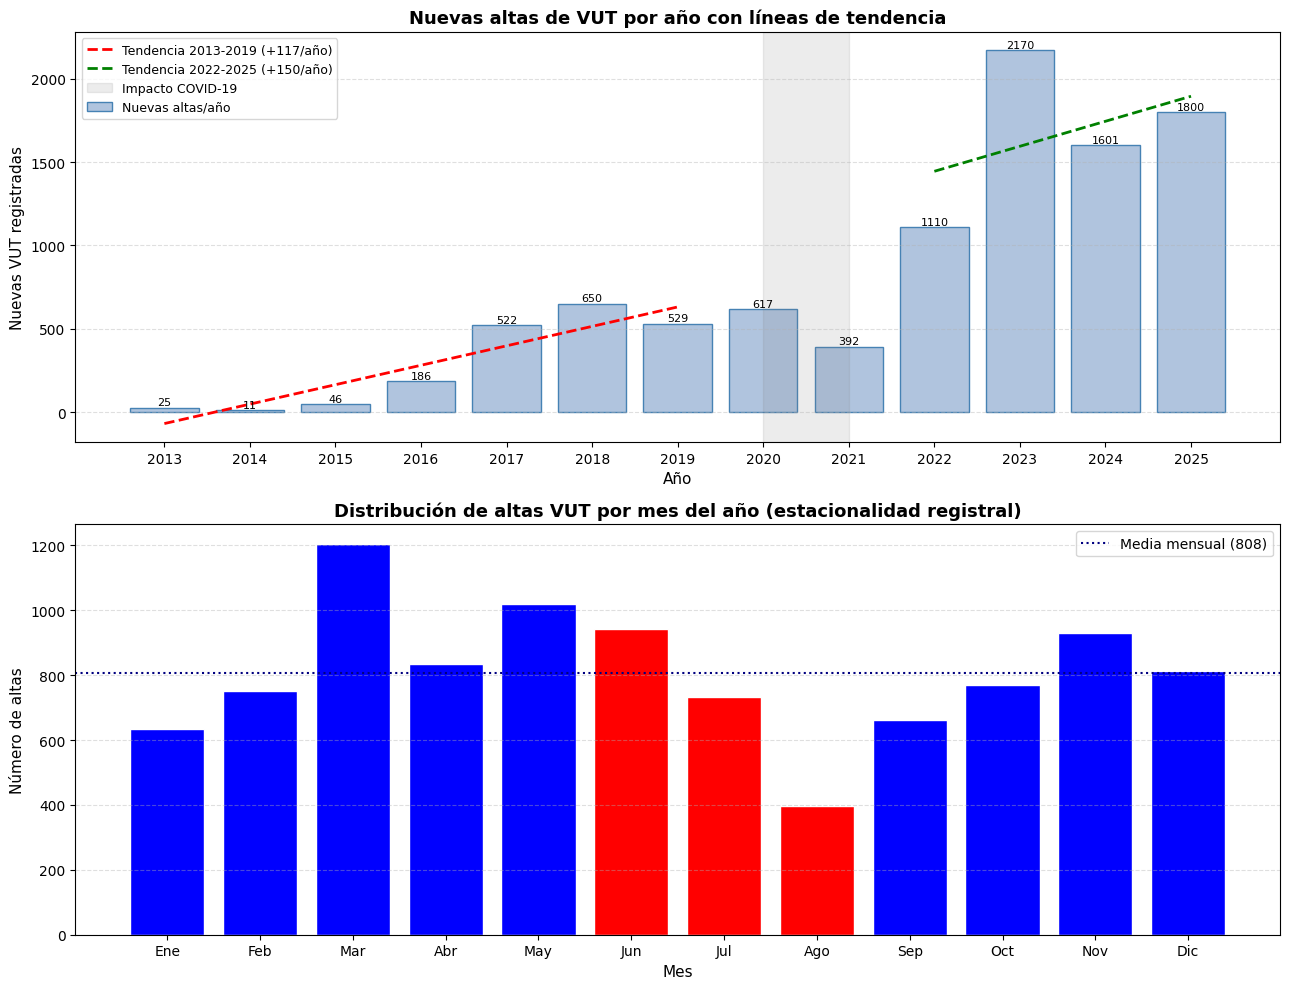

In [ ]:
from scipy import stats

# usar solo años con datos suficientes (>= 2013)
df_ts = altas_anuales[altas_anuales['Año_alta'] >= 2013].copy()

# preiodo 1: 2013-2019 (pre-COVID)
p1 = df_ts[df_ts['Año_alta'] <= 2019]
slope1, intercept1, r1, pval1, _ = stats.linregress(p1['Año_alta'], p1['Nuevas_VUT'])

# periodo 2: 2022-2025 (post-COVID)
p2 = df_ts[df_ts['Año_alta'] >= 2022]
slope2, intercept2, r2, pval2, _ = stats.linregress(p2['Año_alta'], p2['Nuevas_VUT'])

print("ANÁLISIS DE REGRESIÓN LINEAL POR PERIODOS")
print(f"\nPeriodo 2013–2019 (pre-COVID):")
print(f"  Pendiente:   {slope1:+.1f} VUT/año")
print(f"  R²:          {r1**2:.3f}")
print(f"  p-valor:     {pval1:.4f}")

print(f"\nPeriodo 2022–2025 (post-COVID):")
print(f"  Pendiente:   {slope2:+.1f} VUT/año")
print(f"  R²:          {r2**2:.3f}")
print(f"  p-valor:     {pval2:.4f}")

#GRAFICO 

fig, axes = plt.subplots(2, 1, figsize=(13, 10))

# tendencias por subperiodo
ax = axes[0]
ax.bar(df_ts['Año_alta'], df_ts['Nuevas_VUT'], color='lightsteelblue', edgecolor='steelblue', label='Nuevas altas/año')

x1_fit = np.array([2013, 2019])
ax.plot(x1_fit, slope1 * x1_fit + intercept1, 'r--', linewidth=2,
        label=f'Tendencia 2013-2019 (+{slope1:.0f}/año)')

x2_fit = np.array([2022, 2025])
ax.plot(x2_fit, slope2 * x2_fit + intercept2, 'g--', linewidth=2,
        label=f'Tendencia 2022-2025 (+{slope2:.0f}/año)')

ax.axvspan(2020, 2021, alpha=0.15, color='gray', label='Impacto COVID-19')
for _, row in df_ts.iterrows():
    ax.text(row['Año_alta'], row['Nuevas_VUT'] + 15, str(int(row['Nuevas_VUT'])),
            ha='center', fontsize=8)

ax.set_title('Nuevas altas de VUT por año con líneas de tendencia', fontsize=13, fontweight='bold')
ax.set_xlabel('Año', fontsize=11)
ax.set_ylabel('Nuevas VUT registradas', fontsize=11)
ax.legend(fontsize=9)
ax.grid(axis='y', linestyle='--', alpha=0.4)
ax.set_xticks(df_ts['Año_alta'])

# estacionalidad intra-anual del registro
ax2 = axes[1]
altas_por_mes = df_vut_limpio.groupby('Mes_alta').size()
nombres_meses = ['Ene', 'Feb', 'Mar', 'Abr', 'May', 'Jun',
                 'Jul', 'Ago', 'Sep', 'Oct', 'Nov', 'Dic']
colores_mes = ['blue'] * 12
for i in [5, 6, 7]:  # jun, jul, ago
    colores_mes[i] = 'red'

ax2.bar([nombres_meses[m-1] for m in altas_por_mes.index],
        altas_por_mes.values, color=colores_mes, edgecolor='white')
ax2.set_title('Distribución de altas VUT por mes del año (estacionalidad registral)', fontsize=13, fontweight='bold')
ax2.set_xlabel('Mes', fontsize=11)
ax2.set_ylabel('Número de altas', fontsize=11)
ax2.grid(axis='y', linestyle='--', alpha=0.4)
ax2.axhline(altas_por_mes.mean(), color='navy', linestyle=':', linewidth=1.5, label=f'Media mensual ({altas_por_mes.mean():.0f})')
ax2.legend(fontsize=10)

plt.tight_layout()
plt.show()

Los resultados de la regresión por periodos muestran comportamientos muy diferentes. En el periodo **pre-COVID (2013-2019)** se observa una tendencia de crecimiento sostenido, con una pendiente positiva de **+116,6 VUT/año**. El valor de $R^2$ es bastante alto (0.831), lo que indica que el modelo lineal explica gran parte de la variabilidad, y el p-valor significativo (0.0043) nos confirma que esta tendencia creciente es estadísticamente robusta.

En el periodo **post-COVID (2022-2025)** la pendiente estimada es mayor (**+150,1 VUT/año**), lo que sugiere un posible incremento del ritmo de crecimiento. Sin embargo, el valor de $R^2$ es muy bajo (0.192) y el p-valor no es significativo (0.5613), esto nos indica que los datos están demasiado dispersos para asegurar que existe un crecimiento lineal estructural. Por lo tanto, no podemos afrimar con certeza que exista un crecimiento estructural más rápido tras la pandemia.

En cuanto a la estacionalidad registral, los meses de verano (junio-agosto), marcados en rojo, muestran un volumen de altas menor que la media mensual, sobre todo agosto, siendo el minimo del año. El verdadero **"boom" de registros** ocurre en **marzo, mayo y noviembre**. Esto sugiere que los propietarios son previsores: se dan de alta en primavera para tener los papeles listos antes de que empiece la temporada, o en noviembre, aprovechando el cierre del año fiscal o tras comprobar el éxito de la temporada anterior. El bajón de agosto se explica probablemente por el parón administrativo y porque los propietarios están centrados en gestionar el alquiler, no en el papeleo.

### 4.3 CORRELACIÓN VUT – PRECIOS INMOBILIARIOS

La última pregunta es si el crecimiento del sector VUT está relacionado con el encarecimiento de la vivienda en Torrevieja. Para analizarlo, primero visualizamos las dos series de precios de forma independiente para ver su evolución antes de cruzarlas con el stock VUT. Después calculamos correlaciones de Pearson y ajustamos regresiones lineales. Tenemos que tener en cuenta que ambas series tienen tendencia creciente en el tiempo, lo que puede inflar la correlación aunque no haya causalidad directa.

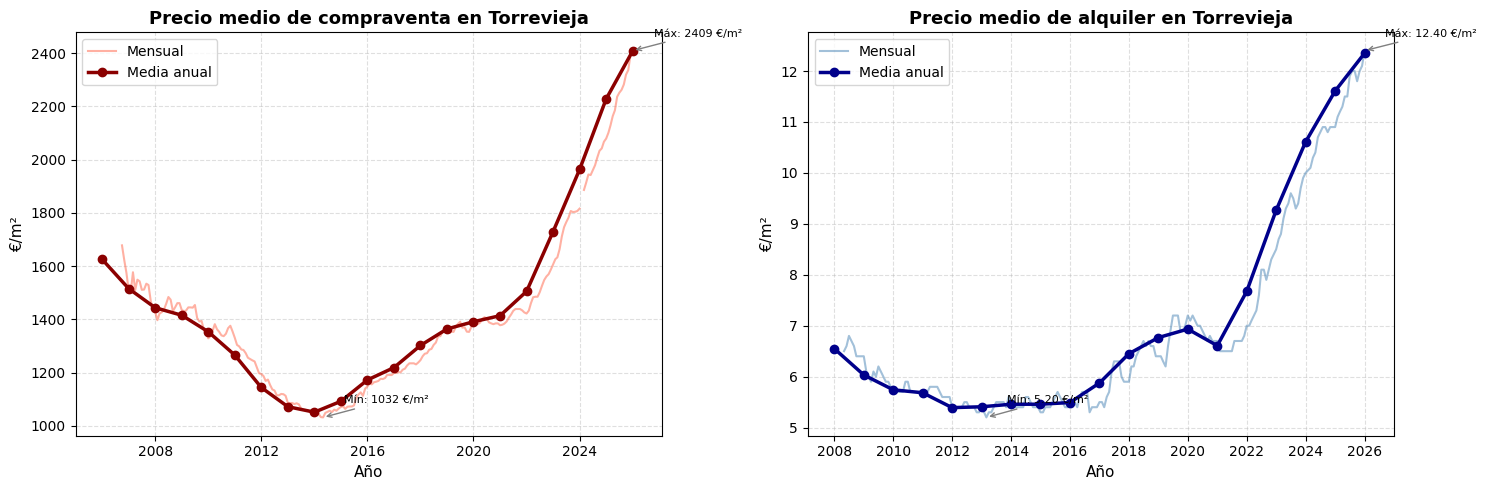

In [ ]:
# antes de cruzarlos con las VUT, vemos cómo han evolucionado los precios solos
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# compraventa: línea mensual + media anual encima para ver la tendencia limpia
ax = axes[0]
ax.plot(df_precio_comp['Fecha'], df_precio_comp['Precio_m2'],
        color='tomato', linewidth=1.5, alpha=0.5, label='Mensual')
precio_anual_comp_plot = df_precio_comp.groupby('Año')['Precio_m2'].mean().reset_index()
ax.plot(pd.to_datetime(precio_anual_comp_plot['Año'].astype(str)),
        precio_anual_comp_plot['Precio_m2'],
        color='darkred', linewidth=2.5, marker='o', label='Media anual')
ax.set_title('Precio medio de compraventa en Torrevieja', fontsize=13, fontweight='bold')
ax.set_xlabel('Año', fontsize=11)
ax.set_ylabel('€/m²', fontsize=11)
ax.grid(linestyle='--', alpha=0.4)
ax.legend(fontsize=10)
idx_min = df_precio_comp['Precio_m2'].idxmin()
idx_max = df_precio_comp['Precio_m2'].idxmax()
for idx, label in [(idx_min, 'Mín'), (idx_max, 'Máx')]:
    row = df_precio_comp.loc[idx]
    ax.annotate(f"{label}: {row['Precio_m2']:.0f} €/m²",
                (row['Fecha'], row['Precio_m2']),
                xytext=(15, 10), textcoords='offset points',
                fontsize=8, arrowprops=dict(arrowstyle='->', color='gray'))

# alquiler
ax2 = axes[1]
ax2.plot(df_precio_alq['Fecha'], df_precio_alq['Precio_m2'],
         color='steelblue', linewidth=1.5, alpha=0.5, label='Mensual')
precio_anual_alq_plot = df_precio_alq.groupby('Año')['Precio_m2'].mean().reset_index()
ax2.plot(pd.to_datetime(precio_anual_alq_plot['Año'].astype(str)),
         precio_anual_alq_plot['Precio_m2'],
         color='darkblue', linewidth=2.5, marker='o', label='Media anual')
ax2.set_title('Precio medio de alquiler en Torrevieja', fontsize=13, fontweight='bold')
ax2.set_xlabel('Año', fontsize=11)
ax2.set_ylabel('€/m²', fontsize=11)
ax2.grid(linestyle='--', alpha=0.4)
ax2.legend(fontsize=10)
idx_min2 = df_precio_alq['Precio_m2'].idxmin()
idx_max2 = df_precio_alq['Precio_m2'].idxmax()
for idx, label in [(idx_min2, 'Mín'), (idx_max2, 'Máx')]:
    row = df_precio_alq.loc[idx]
    ax2.annotate(f"{label}: {row['Precio_m2']:.2f} €/m²",
                 (row['Fecha'], row['Precio_m2']),
                 xytext=(15, 10), textcoords='offset points',
                 fontsize=8, arrowprops=dict(arrowstyle='->', color='gray'))

plt.tight_layout()
plt.show()

Obsrvamos que ambas gráficas muestran que el suelo del mercado llegó entre 2014 y 2015. Este mínimo coincide casi exactamente con el inicio del despegue de las VUT. Mientras los precios de compra bajaron hasta los 1.032 €/m², el alquiler tocó fondo en los 5,20 €/m². A partir de ahí, la tendencia cambia de forma radical.

A partir de 2022, coincidiendo con la "explosión" de altas de VUT que hemos visto en gráficos anteriores, los precios entran en una fase ascendente casi vertical:

- Compraventa: En 2026 alcanza su máximo con 2.409 €/m², esto es más del doble del precio mínimo de 2014.

- Alquiler: Sigue la trayectoria, llegando a los 12,40 €/m². Esto confirma que el mercado de alquiler residencial se ha tensionado al máximo a medida que la vivienda se desvía al uso turístico.

Dataset integrado para análisis de correlación:


,Año,Stock_VUT_Acumulado,Precio_compra_m2,Precio_alq_m2
4,2015,117,1092.3,5.5
5,2016,303,1172.5,5.5
6,2017,825,1219.0,5.9
7,2018,1475,1302.1,6.4
8,2019,2004,1364.1,6.8
9,2020,2621,1391.2,6.9
10,2021,3013,1413.9,6.6
11,2022,4123,1505.2,7.7
12,2023,6293,1729.5,9.3
13,2024,7894,1962.8,10.6



Correlación de Pearson (Stock VUT vs. Precio compraventa): +0.993
Correlación de Pearson (Stock VUT vs. Precio alquiler):    +0.993

Regresión VUT → Precio compraventa: β=0.1088, R²=0.987, p=9.092983576872112e-10
Regresión VUT → Precio alquiler:    β=0.0006, R²=0.986, p=1.275005858796448e-09


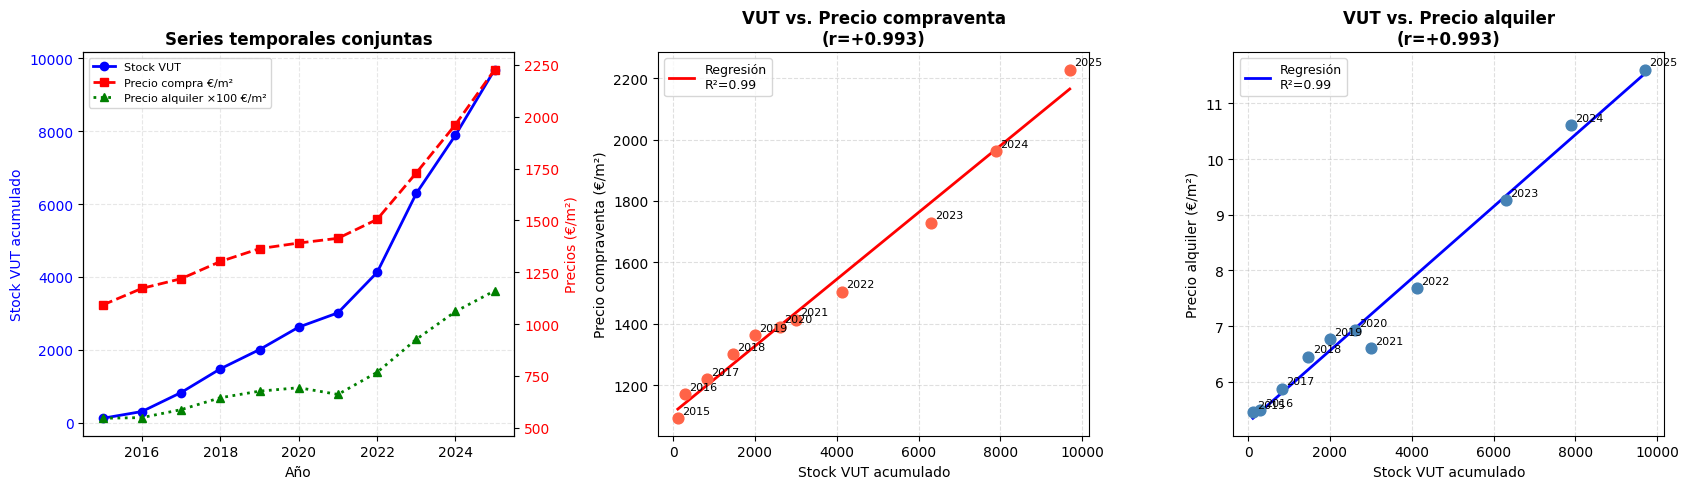

In [ ]:
# stock VUT anual
df_stock = altas_anuales[['Año_alta', 'Stock_VUT_Acumulado']].rename(columns={'Año_alta': 'Año'})

# precio medio anual de compraventa y alquiler
df_precio_comp['Precio_m2'] = pd.to_numeric(df_precio_comp['Precio_m2'], errors='coerce')
precio_anual_comp = df_precio_comp.groupby('Año')['Precio_m2'].mean().reset_index()
precio_anual_comp.columns = ['Año', 'Precio_compra_m2']

precio_anual_alq = df_precio_alq.groupby('Año')['Precio_m2'].mean().reset_index()
precio_anual_alq.columns = ['Año', 'Precio_alq_m2']

# juntamos y filtramos desde 2015 (a partir de cuando el sector ya tiene masa suficiente)
df_corr = df_stock.merge(precio_anual_comp, on='Año', how='inner') \
                  .merge(precio_anual_alq,  on='Año', how='inner')
df_corr = df_corr[df_corr['Año'] >= 2015].copy()

print("Dataset integrado para análisis de correlación:")
display(df_corr.round(1))

corr_comp = df_corr['Stock_VUT_Acumulado'].corr(df_corr['Precio_compra_m2'])
corr_alq  = df_corr['Stock_VUT_Acumulado'].corr(df_corr['Precio_alq_m2'])
print(f"\nCorrelación de Pearson (Stock VUT vs. Precio compraventa): {corr_comp:+.3f}")
print(f"Correlación de Pearson (Stock VUT vs. Precio alquiler):    {corr_alq:+.3f}")

slope_c, intercept_c, r_c, pval_c, _ = stats.linregress(df_corr['Stock_VUT_Acumulado'], df_corr['Precio_compra_m2'])
slope_a, intercept_a, r_a, pval_a, _ = stats.linregress(df_corr['Stock_VUT_Acumulado'], df_corr['Precio_alq_m2'])
print(f"\nRegresión VUT → Precio compraventa: β={slope_c:.4f}, R²={r_c**2:.3f}, p={pval_c}")
print(f"Regresión VUT → Precio alquiler:    β={slope_a:.4f}, R²={r_a**2:.3f}, p={pval_a}")

fig, axes = plt.subplots(1, 3, figsize=(17, 5))

# series temporales conjuntas con doble eje
ax = axes[0]
ax_r = ax.twinx()
ax.plot(df_corr['Año'], df_corr['Stock_VUT_Acumulado'], 'bo-', linewidth=2, label='Stock VUT')
ax_r.plot(df_corr['Año'], df_corr['Precio_compra_m2'], 'rs--', linewidth=2, label='Precio compra €/m²')
ax_r.plot(df_corr['Año'], df_corr['Precio_alq_m2'] * 100, 'g^:', linewidth=2, label='Precio alquiler ×100 €/m²')
ax.set_xlabel('Año', fontsize=10)
ax.set_ylabel('Stock VUT acumulado', fontsize=10, color='blue')
ax_r.set_ylabel('Precios (€/m²)', fontsize=10, color='red')
ax.tick_params(axis='y', labelcolor='blue')
ax_r.tick_params(axis='y', labelcolor='red')
lines1, labs1 = ax.get_legend_handles_labels()
lines2, labs2 = ax_r.get_legend_handles_labels()
ax.legend(lines1 + lines2, labs1 + labs2, fontsize=8, loc='upper left')
ax.set_title('Series temporales conjuntas', fontsize=12, fontweight='bold')
ax.grid(linestyle='--', alpha=0.3)

# scatter VUT vs compraventa
ax2 = axes[1]
ax2.scatter(df_corr['Stock_VUT_Acumulado'], df_corr['Precio_compra_m2'], color='tomato', s=60, zorder=3)
for _, row in df_corr.iterrows():
    ax2.annotate(str(int(row['Año'])), (row['Stock_VUT_Acumulado'], row['Precio_compra_m2']),
                 fontsize=8, xytext=(3, 3), textcoords='offset points')
x_line = np.linspace(df_corr['Stock_VUT_Acumulado'].min(), df_corr['Stock_VUT_Acumulado'].max(), 100)
ax2.plot(x_line, slope_c * x_line + intercept_c, 'r-', linewidth=2, label=f'Regresión\nR²={r_c**2:.2f}')
ax2.set_xlabel('Stock VUT acumulado', fontsize=10)
ax2.set_ylabel('Precio compraventa (€/m²)', fontsize=10)
ax2.set_title(f'VUT vs. Precio compraventa\n(r={corr_comp:+.3f})', fontsize=12, fontweight='bold')
ax2.legend(fontsize=9)
ax2.grid(linestyle='--', alpha=0.4)

# scatter VUT vs alquiler
ax3 = axes[2]
ax3.scatter(df_corr['Stock_VUT_Acumulado'], df_corr['Precio_alq_m2'], color='steelblue', s=60, zorder=3)
for _, row in df_corr.iterrows():
    ax3.annotate(str(int(row['Año'])), (row['Stock_VUT_Acumulado'], row['Precio_alq_m2']),
                 fontsize=8, xytext=(3, 3), textcoords='offset points')
ax3.plot(x_line, slope_a * x_line + intercept_a, 'b-', linewidth=2, label=f'Regresión\nR²={r_a**2:.2f}')
ax3.set_xlabel('Stock VUT acumulado', fontsize=10)
ax3.set_ylabel('Precio alquiler (€/m²)', fontsize=10)
ax3.set_title(f'VUT vs. Precio alquiler\n(r={corr_alq:+.3f})', fontsize=12, fontweight='bold')
ax3.legend(fontsize=9)
ax3.grid(linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()


Observamos que las correlaciones son muy altas (mayor que 0.99), tanto para el precio de compraventa como para el de alquiler. Sin embargo, hay que tener en cuenta que las series paralelas de precio y VUT comparten una tendencia temporal creciente, lo que infla artificialmente la correlación de Pearson.

La coincidencia temporal entre la aceleración del stock de VUT a partir de 2022 coincide con el tramo más pronunciado de subida de precios en toda la serie histórica. Los valores de $R^2$ (0.98 y 0.99) y los p-valores casi nulos indican que la relación no es aleatoria.

Aunque el análisis de correlación no nos permite establecer una causalidad directa (es decir, no podemos afirmar que las VUT sean la única causa), los resultados son muy coherentes con la hipótesis de presión inmobiliaria: el trasvase masivo de viviendas al mercado turístico coincide con un encarecimiento sin precedentes tanto para el comprador como para el inquilino en Torrevieja.

## 5. CONCLUSIONES

El análisis del sector de las Viviendas de Uso Turístico (VUT) en Torrevieja nos permite responder a las cuatro preguntas planteadas al inicio.

#### 5.1 Dimensión y peso del sector

Torrevieja tiene cerca de **9.900 VUT registradas** que generan más de **39.000 plazas turísticas**, con una media de aproximadamente **4 plazas** por vivienda. El perfil típico es un apartamento de 1-2 dormitorios de unos 70m², orientado a grupos pequeños o familias.

Sobre el total del parque de viviendas censado, las VUT representan el **7,9%** del total censado en 2021. Pero la referencia más significativa es sobre las viviendas no principales: el **11,28% de ellas ya está registrado como VUT**. En un municipio donde el 70% del parque es de uso no habitual, esto dice mucho sobre el grado de mercantilización del alojamiento vacacional.

#### 5.2 Tendencia temporal: un sector en aceleración

El registro muestra un sector en tres etapas: crecimiento moderado hasta 2017, una fase de aceleración previa a la pandemia, interrupción por el COVID en 2020-2021, y una expansión post-pandemia que supera todo lo anterior con **2.170 altas anuales en 2023**. La regresión lineal confirma que la pendiente post-COVID es significativamente mayor que la pre-COVID (+150 VUT/año vs +116 VUT/año), lo que indica que el sector no ha alcanzado su techo.

#### 5.3 Concentración territorial y perfiles de zona

El análisis de clustering (k=2) identifica dos perfiles claros: **el Centro (CP 03180)** concentra alrededor del **60% de las VUT**, Son viviendas más pequeñas (**70 m²**) y con un ritmo de registro actual frenético. **Las zonas periféricas (03181-03186)** tienen una densidad mucho menor pero con viviendas más grandes (hasta **157 m²** de media en algunos puntos) y mayor capacidad de plazas, orientadas a otro tipo de turista. Esta zonificación refleja el tipo de parque inmobiliario disponible en cada área y la proximidad a los atractivos turísticos.

La concentración en el centro es relevante desde el punto de vista de la política de vivienda: es precisamente donde el mercado de alquiler residencial tiene más demanda, y donde la competencia con el uso turístico puede ser más intensa.

#### 5.4 Relación con precios inmobiliarios

La correlación entre el stock de VUT y los precios de compraventa y alquiler es casi perfecta (mayor que 0.99). Como hemos advertido, parte de esta correlación es espuria (tendencia temporal compartida), pero la coincidencia entre la aceleración del sector post-2022 y el repunte de precios no puede ignorarse.

#### Conclusión final

Torrevieja es una ciudad de alojamiento turístico residencial. Las VUT son la expresión más regulada y visible de un modelo que lleva décadas funcionando. Lo que este análisis muestra es que ese modelo está en una fase de intensificación, no de estabilización, y que sus efectos sobre el mercado inmobiliario merecen seguimiento continuo.

## 6. LIMITACIONES DEL ANÁLISIS

**Limitaciones de los datos disponibles:**

1. **Ausencia de datos de bajas en el registro**: el archivo de VUT solo contiene las actualmente dadas de alta. La evolución por `fecha_alta` sobreestima el stock real en cada corte temporal, ya que no quita las viviendas que se han dado de baja.

2. **Brecha registro oficial / oferta real en plataformas**: la oferta visible en Airbnb o Booking puede incluir viviendas no registradas. Con nuestros datos no podemos cuantificar esta brecha en Torrevieja.

3. **Censos cada 10 años**: los datos del parque de viviendas (2001, 2011, 2021) no nos permiten seguir la evolución anual. La estimación del porcentaje de VUT sobre el parque puede estar sesgada si este ha crecido significativamente entre censos.

4. **Precios sin desagregación territorial**: los precios de compraventa y alquiler son un agregado municipal. No sabemos si la presión sobre los precios es mayor en las zonas con más VUT.

5. **Correlación vs. causalidad**: la relación entre VUT y precios no implica causalidad. Otros factores simultáneos pueden explicar ambas variables, aunque la coincidencia temporal con el auge VUT es un indicador de peso.
